In [ ]:
import cv2
import dlib
import numpy as np
import random
import os


detector = dlib.get_frontal_face_detector()
predictor_path = r"D:\Occlusions\Landmark_predictor_path\shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(predictor_path)

def load_image(path):
    try:
        with open(path, 'rb') as f:
            data = np.frombuffer(f.read(), dtype=np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except:
        return cv2.imread(path)


def add_upper_occlusion_cover_eyes(img, landmarks):
    h, w = img.shape[:2]
    
    eye_points = [(landmarks.part(i).x, landmarks.part(i).y) for i in range(36, 48)]
    
    eyes_min_x = min(p[0] for p in eye_points)
    eyes_max_x = max(p[0] for p in eye_points)
    eyes_min_y = min(p[1] for p in eye_points)
    eyes_max_y = max(p[1] for p in eye_points)
    
    eyes_width = eyes_max_x - eyes_min_x
    eyes_height = eyes_max_y - eyes_min_y

    occ_width = int(eyes_width * random.uniform(1.2, 2.0))
    occ_height = int(eyes_height * random.uniform(1.6, 4.0))
    
    center_x = (eyes_min_x + eyes_max_x) // 2
    center_y = (eyes_min_y + eyes_max_y) // 2
    x = center_x - occ_width // 2
    y = center_y - occ_height // 2
    
    x += random.randint(-int(occ_width*0.15), int(occ_width*0.15))
    y += random.randint(-int(occ_height*0.1), int(occ_height*0.1))
    
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(w, x + occ_width)
    y2 = min(h, y + occ_height)
    
    if x2 <= x1 or y2 <= y1:
        return img
    
    actual_width = x2 - x1
    actual_height = y2 - y1
    
    color = (random.randint(0, 50), random.randint(0, 50), random.randint(0, 50))
    
    alpha = random.uniform(0.6, 0.95)
    
    shape = random.choice(['rectangle', 'ellipse'])
    
    overlay = img.copy()
    
    if shape == 'rectangle':
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    else:
        center = (x1 + actual_width // 2, y1 + actual_height // 2)
        axes = (actual_width // 2, actual_height // 2)
        cv2.ellipse(overlay, center, axes, 0, 0, 360, color, -1)
    
    result = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    return result


def batch_apply_occlusions_to_folder(input_dir, output_dir, occlusion_ratio=0.7):
    
    os.makedirs(output_dir, exist_ok=True)
    
    images = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(os.path.join(root, file))
    
    print(f"Найдено изображений: {len(images)}")
    
    stats = {
        'upper': 0,
        'no_face': 0,
        'original': 0
    }
    
    for i, img_path in enumerate(images):
        try:
            img = load_image(img_path)
            if img is None:
                stats['no_face'] += 1
                continue
            
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)
            
            if len(faces) == 0:
                stats['no_face'] += 1
                rel_path = os.path.relpath(img_path, input_dir)
                output_path = os.path.join(output_dir, rel_path)
                os.makedirs(os.path.dirname(output_path), exist_ok=True)
                cv2.imwrite(output_path, img)
                continue
            
            face = faces[0]
            landmarks = predictor(gray, face)
            
            if random.random() < occlusion_ratio:
                result = add_upper_occlusion_cover_eyes(img, landmarks, face)
                stats['upper'] += 1
            else:
                result = img
                stats['original'] += 1
            
            rel_path = os.path.relpath(img_path, input_dir)
            output_path = os.path.join(output_dir, rel_path)
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            cv2.imwrite(output_path, result)
            
            if (i + 1) % 100 == 0:
                print(f"Прогресс: {i+1}/{len(images)} "
                      f"(очки: {stats['upper']})")
                
        except Exception as e:
            print(f"Ошибка: {img_path} - {e}")
    
    print(f"СТАТИСТИКА:")
    print(f"   Очки/повязка: {stats['upper']}")
    print(f"   Оригинал: {stats['original']}")
    print(f"   Лицо не найдено: {stats['no_face']}")
    print(f"   Всего обработано: {len(images)}")
    print(f"   Доля оклюзий: {occlusion_ratio*100:.0f}%")
    print(f"\nРезультаты в {output_dir}")


if __name__ == "__main__":
    batch_apply_occlusions_to_folder(
        input_dir=r"D:\НИР\RAF-DB\DATASET\test",
        output_dir=r"D:\Occlusions\occluded_test_dataset_upper",
        occlusion_ratio=0.7
    )

Найдено изображений: 3068
Прогресс: 100/3068 (очки: 47)
Прогресс: 200/3068 (очки: 96)
Прогресс: 300/3068 (очки: 149)
Прогресс: 400/3068 (очки: 205)
Прогресс: 500/3068 (очки: 259)
Прогресс: 600/3068 (очки: 308)
Прогресс: 700/3068 (очки: 364)
Прогресс: 800/3068 (очки: 424)
Прогресс: 900/3068 (очки: 483)
Прогресс: 1000/3068 (очки: 536)
Прогресс: 1100/3068 (очки: 601)
Прогресс: 1200/3068 (очки: 654)
Прогресс: 1300/3068 (очки: 706)
Прогресс: 1400/3068 (очки: 770)
Прогресс: 1500/3068 (очки: 833)
Прогресс: 1600/3068 (очки: 892)
Прогресс: 1700/3068 (очки: 948)
Прогресс: 1800/3068 (очки: 1000)
Прогресс: 1900/3068 (очки: 1055)
Прогресс: 2100/3068 (очки: 1171)
Прогресс: 2200/3068 (очки: 1226)
Прогресс: 2300/3068 (очки: 1268)
Прогресс: 2500/3068 (очки: 1362)
Прогресс: 2600/3068 (очки: 1403)
Прогресс: 2700/3068 (очки: 1452)
Прогресс: 2800/3068 (очки: 1505)
СТАТИСТИКА:
   Очки/повязка: 1620
   Оригинал: 692
   Лицо не найдено: 756
   Всего обработано: 3068
   Доля оклюзий: 70%

Результаты в D:\Occlu

In [ ]:
import cv2
import dlib
import numpy as np
import random
import os


detector = dlib.get_frontal_face_detector()
predictor_path = r"D:\Occlusions\Landmark_predictor_path\shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(predictor_path)

def load_image(path):
    try:
        with open(path, 'rb') as f:
            data = np.frombuffer(f.read(), dtype=np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except:
        return cv2.imread(path)


def add_lower_occlusion_cover_mouth(img, landmarks):
    h, w = img.shape[:2]
    
    mouth_points = [(landmarks.part(i).x, landmarks.part(i).y) for i in range(48, 68)]

    mouth_min_x = min(p[0] for p in mouth_points)
    mouth_max_x = max(p[0] for p in mouth_points)
    mouth_min_y = min(p[1] for p in mouth_points)
    mouth_max_y = max(p[1] for p in mouth_points)
    
    mouth_width = mouth_max_x - mouth_min_x
    mouth_height = mouth_max_y - mouth_min_y
    
    occ_width = int(mouth_width * random.uniform(1.2, 2.4))
    occ_height = int(mouth_height * random.uniform(1.2, 2.4))
    
    center_x = (mouth_min_x + mouth_max_x) // 2
    center_y = (mouth_min_y + mouth_max_y) // 2
    x = center_x - occ_width // 2
    y = center_y - occ_height // 2
    
    x += random.randint(-int(occ_width*0.15), int(occ_width*0.15))
    y += random.randint(-int(occ_height*0.1), int(occ_height*0.1))
    
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(w, x + occ_width)
    y2 = min(h, y + occ_height)
    
    if x2 <= x1 or y2 <= y1:
        return img
    
    actual_width = x2 - x1
    actual_height = y2 - y1
    
    color_options = [
        (random.randint(150, 220), random.randint(150, 220), random.randint(150, 220)),
        (random.randint(100, 180), random.randint(150, 220), random.randint(200, 240)),
        (random.randint(180, 220), random.randint(180, 220), random.randint(200, 240)),
    ]
    color = random.choice(color_options)
    
    alpha = random.uniform(0.7, 0.95)

    shape = random.choice(['rectangle', 'ellipse'])
    
    overlay = img.copy()
    
    if shape == 'rectangle':
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    else:
        center = (x1 + actual_width // 2, y1 + actual_height // 2)
        axes = (actual_width // 2, actual_height // 2)
        cv2.ellipse(overlay, center, axes, 0, 0, 360, color, -1)
    
    result = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    return result


def batch_apply_occlusions_to_folder(input_dir, output_dir, occlusion_ratio=0.7):
    
    os.makedirs(output_dir, exist_ok=True)
    
    images = []
    for root, dirs, files in os.walk(input_dir):
        for file in files:
            if file.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(os.path.join(root, file))
    
    print(f"Найдено изображений: {len(images)}")
    
    stats = {
        'lower': 0,
        'no_face': 0,
        'original': 0
    }
    
    for i, img_path in enumerate(images):
        try:
            img = load_image(img_path)
            if img is None:
                stats['no_face'] += 1
                continue
            
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            faces = detector(gray)
            
            if len(faces) == 0:
                stats['no_face'] += 1
                rel_path = os.path.relpath(img_path, input_dir)
                output_path = os.path.join(output_dir, rel_path)
                os.makedirs(os.path.dirname(output_path), exist_ok=True)
                cv2.imwrite(output_path, img)
                continue
            
            face = faces[0]
            landmarks = predictor(gray, face)
            
            if random.random() < occlusion_ratio:
                result = add_lower_occlusion_cover_mouth(img, landmarks, face)
                stats['lower'] += 1
            else:
                result = img
                stats['original'] += 1
            
            rel_path = os.path.relpath(img_path, input_dir)
            output_path = os.path.join(output_dir, rel_path)
            os.makedirs(os.path.dirname(output_path), exist_ok=True)
            cv2.imwrite(output_path, result)
            
            if (i + 1) % 100 == 0:
                print(f"Прогресс: {i+1}/{len(images)} "
                      f"(маски: {stats['lower']})")
                
        except Exception as e:
            print(f"Ошибка: {img_path} - {e}")
    
    print(f"СТАТИСТИКА:")
    print(f"   Маска: {stats['lower']}")
    print(f"   Оригинал: {stats['original']}")
    print(f"   Лицо не найдено: {stats['no_face']}")
    print(f"   Всего обработано: {len(images)}")
    print(f"   Доля оклюзий: {occlusion_ratio*100:.0f}%")
    print(f"\nРезультаты в {output_dir}")


if __name__ == "__main__":
    batch_apply_occlusions_to_folder(
        input_dir=r"D:\НИР\RAF-DB\DATASET\test",
        output_dir=r"D:\Occlusions\occluded_test_dataset_lower",
        occlusion_ratio=0.7
    )

Найдено изображений: 3068
Прогресс: 100/3068 (маски: 50)
Прогресс: 200/3068 (маски: 99)
Прогресс: 300/3068 (маски: 154)
Прогресс: 400/3068 (маски: 202)
Прогресс: 500/3068 (маски: 258)
Прогресс: 600/3068 (маски: 309)
Прогресс: 700/3068 (маски: 364)
Прогресс: 800/3068 (маски: 425)
Прогресс: 900/3068 (маски: 487)
Прогресс: 1000/3068 (маски: 549)
Прогресс: 1100/3068 (маски: 607)
Прогресс: 1200/3068 (маски: 653)
Прогресс: 1300/3068 (маски: 707)
Прогресс: 1400/3068 (маски: 772)
Прогресс: 1500/3068 (маски: 826)
Прогресс: 1600/3068 (маски: 885)
Прогресс: 1700/3068 (маски: 942)
Прогресс: 1800/3068 (маски: 992)
Прогресс: 1900/3068 (маски: 1040)
Прогресс: 2100/3068 (маски: 1140)
Прогресс: 2200/3068 (маски: 1179)
Прогресс: 2300/3068 (маски: 1218)
Прогресс: 2500/3068 (маски: 1305)
Прогресс: 2600/3068 (маски: 1354)
Прогресс: 2700/3068 (маски: 1404)
Прогресс: 2800/3068 (маски: 1455)
СТАТИСТИКА:
   Маска: 1587
   Оригинал: 725
   Лицо не найдено: 756
   Всего обработано: 3068
   Доля оклюзий: 70%

Рез

c:\Users\Pulse_GL66\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


СРАВНЕНИЕ РЕЗУЛЬТАТОВ на EFFICIENTNET-B2

===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model (15).pth
  Загружена модель с эпохи 32, val acc = 86.20%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:13<00:00,  6.95it/s]


Результаты модели на тесте
Всего изображений: 3068

Accuracy: 86.15%
Macro F1-Score: 0.7807

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.869        0.863        0.866       
Fear         0.652        0.581        0.614       
Disgust      0.656        0.500        0.567       
Happiness    0.952        0.938        0.945       
Sadness      0.832        0.858        0.844       
Anger        0.814        0.784        0.799       
Neutral      0.798        0.863        0.829       


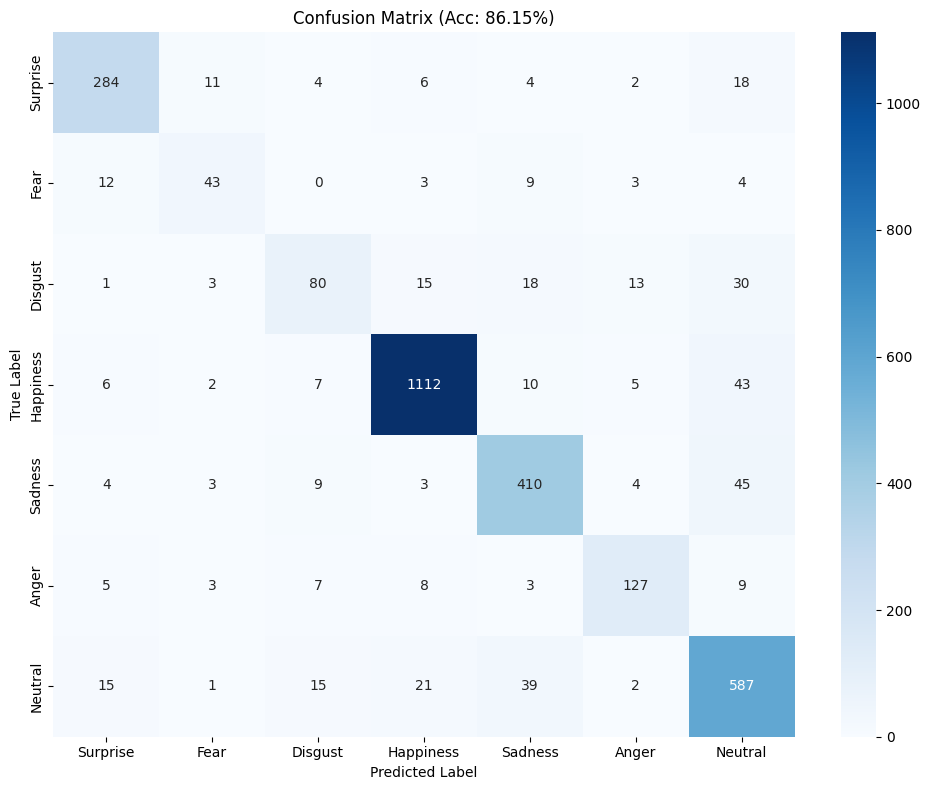


===RAF-DB TEST С ОККЛЮЗИЯМИ===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model (15).pth
  Загружена модель с эпохи 32, val acc = 86.20%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:30<00:00,  3.15it/s]


Результаты модели на тесте
Всего изображений: 3068

Accuracy: 80.48%
Macro F1-Score: 0.7236

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.828        0.775        0.801       
Fear         0.627        0.500        0.556       
Disgust      0.551        0.469        0.507       
Happiness    0.947        0.853        0.897       
Sadness      0.762        0.816        0.788       
Anger        0.753        0.735        0.744       
Neutral      0.704        0.856        0.772       


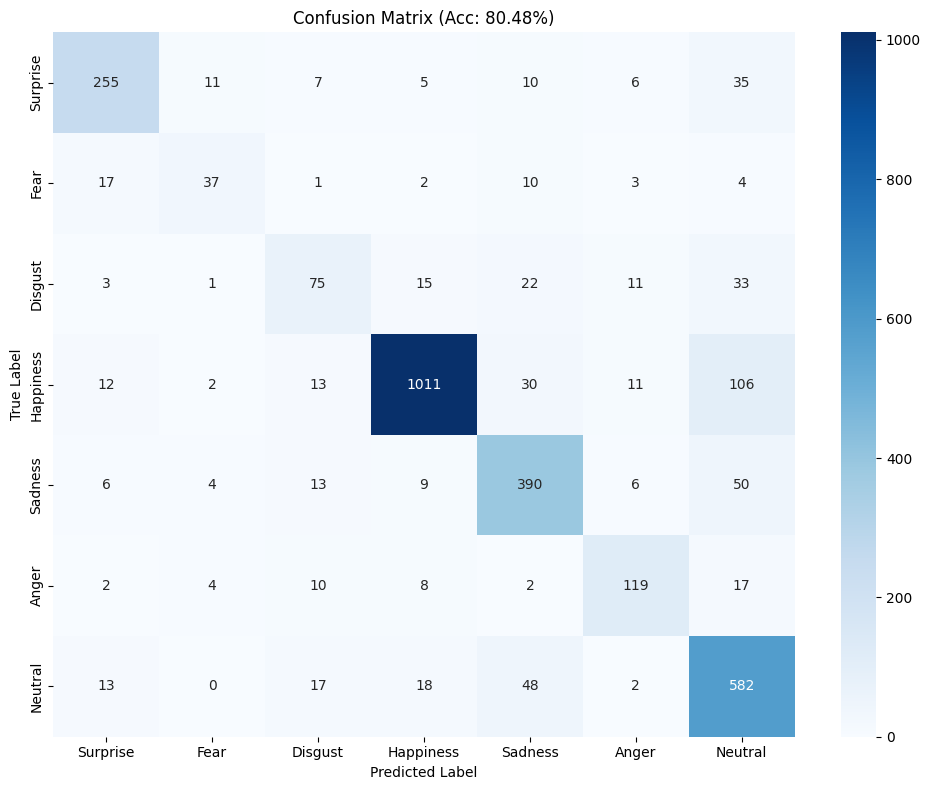

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.15%
Тест с окклюзиями:   Accuracy = 80.48%
Падение качества:      5.67%


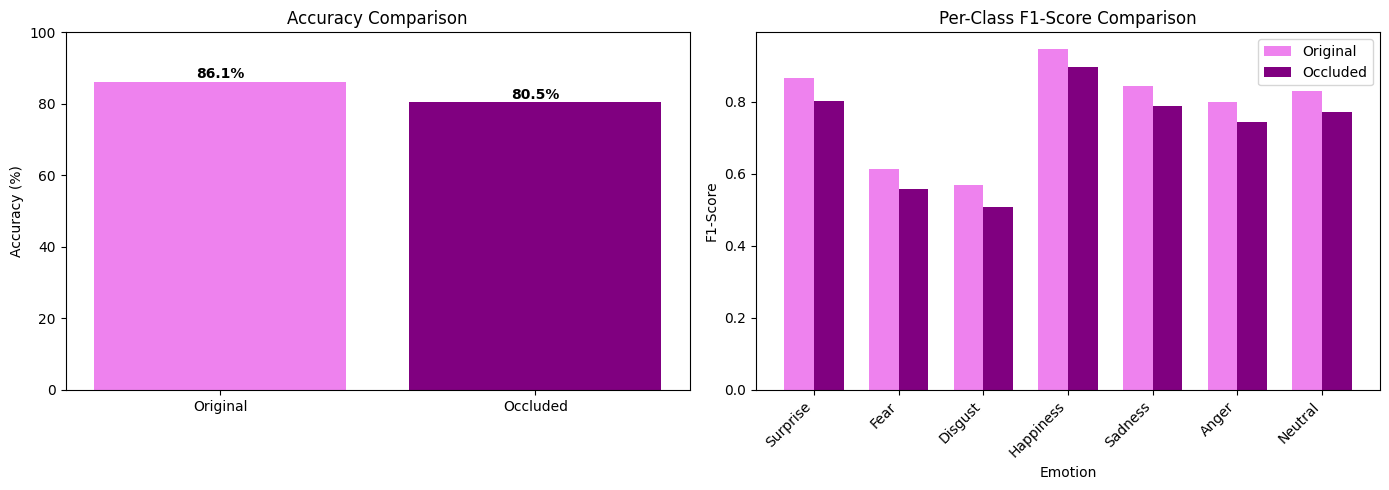

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path


class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        
        weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b2(weights=weights)
        in_features = 1408
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        
    
    def forward(self, x):
        return self.backbone(x)


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue
        
        print(f"Загружено {len(self.images)} изображений из {self.root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), img_path


def test_on_occluded_dataset(model_path, test_dir, batch_size=32, save_results=True):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")
    
    print(f"\nЗагрузка модели из {model_path}")
    model = EfficientNetEmotion(num_classes=7, pretrained=True).to(device)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Загружена модель с эпохи {checkpoint.get('epoch', '?')}, "
          f"val acc = {checkpoint.get('val_acc', '?'):.2f}%")
    
    model = model.to(device)
    model.eval()
    
    print(f"\nЗагрузка тестовых данных из {test_dir}")

    test_dataset = TestDataset(test_dir)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nТестирование на {len(test_dataset)} изображениях")
    
    all_preds = []
    all_labels = []
    all_paths = []
    
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust',
        3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }
    
    with torch.no_grad():
        for inputs, labels, paths in tqdm(test_loader, desc='Тестирование'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    
    valid_indices = [i for i, l in enumerate(all_labels) if l != -1]
    valid_preds = [all_preds[i] for i in valid_indices]
    valid_labels = [all_labels[i] for i in valid_indices]
    valid_paths = [all_paths[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labels, valid_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average='macro', zero_division=0
    )
    
    print(f"Результаты модели на тесте")
    print(f"Всего изображений: {len(test_dataset)}")
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    
    print(f"\nPer-class metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 48)
    for i in range(7):
        print(f"{emotion_labels[i]:<12} {precision[i]:<12.3f} {recall[i]:<12.3f} {f1[i]:<12.3f}")
    
    cm = confusion_matrix(valid_labels, valid_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title(f'Confusion Matrix (Acc: {accuracy:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    plt.show()
        
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_f1': f1,
        'confusion_matrix': cm,
        'predictions': valid_preds,
        'true_labels': valid_labels
    }


def compare_results(original_test_path, occluded_test_path, model_path):
    print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ на EFFICIENTNET-B2")
    
    print("\n===ОРИГИНАЛЬНЫЙ RAF-DB TEST===\n")
    original_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=original_test_path,
        batch_size=32,
        save_results=False
    )
    
    print("\n===RAF-DB TEST С ОККЛЮЗИЯМИ===\n")
    occluded_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=occluded_test_path,
        batch_size=32,
        save_results=True
    )
    
    if original_results and occluded_results:
        print("Сравнительный анализ:")
        print(f"Оригинальный тест:     Accuracy = {original_results['accuracy']:.2f}%")
        print(f"Тест с окклюзиями:   Accuracy = {occluded_results['accuracy']:.2f}%")
        print(f"Падение качества:      {original_results['accuracy'] - occluded_results['accuracy']:.2f}%")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        ax[0].bar(['Original', 'Occluded'], 
                  [original_results['accuracy'], occluded_results['accuracy']],
                  color=['violet', 'purple'])
        ax[0].set_ylabel('Accuracy (%)')
        ax[0].set_title('Accuracy Comparison')
        ax[0].set_ylim(0, 100)
        for i, v in enumerate([original_results['accuracy'], occluded_results['accuracy']]):
            ax[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        
        x = np.arange(7)
        width = 0.35
        ax[1].bar(x - width/2, original_results['per_class_f1'], width, label='Original', color='violet')
        ax[1].bar(x + width/2, occluded_results['per_class_f1'], width, label='Occluded', color='purple')
        ax[1].set_xlabel('Emotion')
        ax[1].set_ylabel('F1-Score')
        ax[1].set_title('Per-Class F1-Score Comparison')
        ax[1].set_xticks(x)
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        ax[1].set_xticklabels(emotion_labels, rotation=45, ha='right')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    MODEL_PATH = r"C:\Users\Pulse_GL66\Downloads\best_model (15).pth"
    ORIGINAL_TEST_PATH = r"D:\НИР\RAF-DB\DATASET\test"
    OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset"
    
    compare_results(ORIGINAL_TEST_PATH, OCCLUDED_TEST_PATH, MODEL_PATH)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА EFFICIENTNET-B2

===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model (15).pth
  Загружена модель с эпохи 32, val acc = 86.20%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:12<00:00,  7.70it/s]


Результаты модели на тесте
Всего изображений: 3068

Accuracy: 86.15%
Macro F1-Score: 0.7807

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.869        0.863        0.866       
Fear         0.652        0.581        0.614       
Disgust      0.656        0.500        0.567       
Happiness    0.952        0.938        0.945       
Sadness      0.832        0.858        0.844       
Anger        0.814        0.784        0.799       
Neutral      0.798        0.863        0.829       


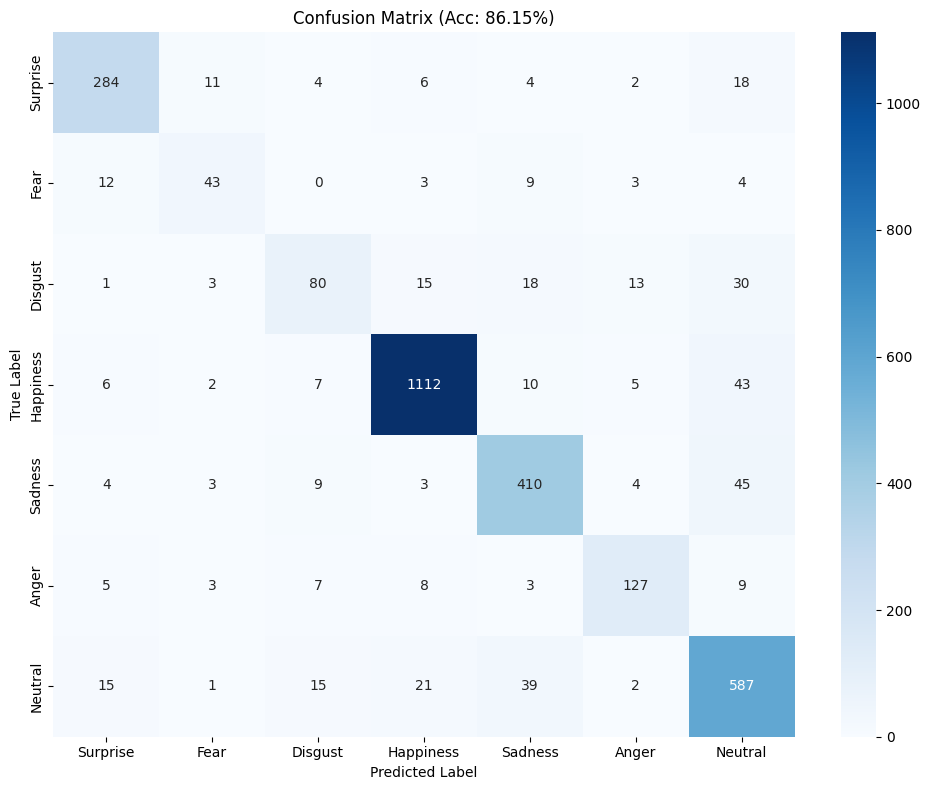


===RAF-DB TEST С ОККЛЮЗИЯМИ В НИЖНЕЙ ЧАСТИ ЛИЦА===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model (15).pth
  Загружена модель с эпохи 32, val acc = 86.20%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset_lower
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset_lower

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:36<00:00,  2.66it/s]


Результаты модели на тесте
Всего изображений: 3068

Accuracy: 78.36%
Macro F1-Score: 0.7009

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.803        0.778        0.790       
Fear         0.609        0.378        0.467       
Disgust      0.534        0.494        0.513       
Happiness    0.952        0.802        0.870       
Sadness      0.737        0.851        0.790       
Anger        0.774        0.698        0.734       
Neutral      0.665        0.840        0.742       


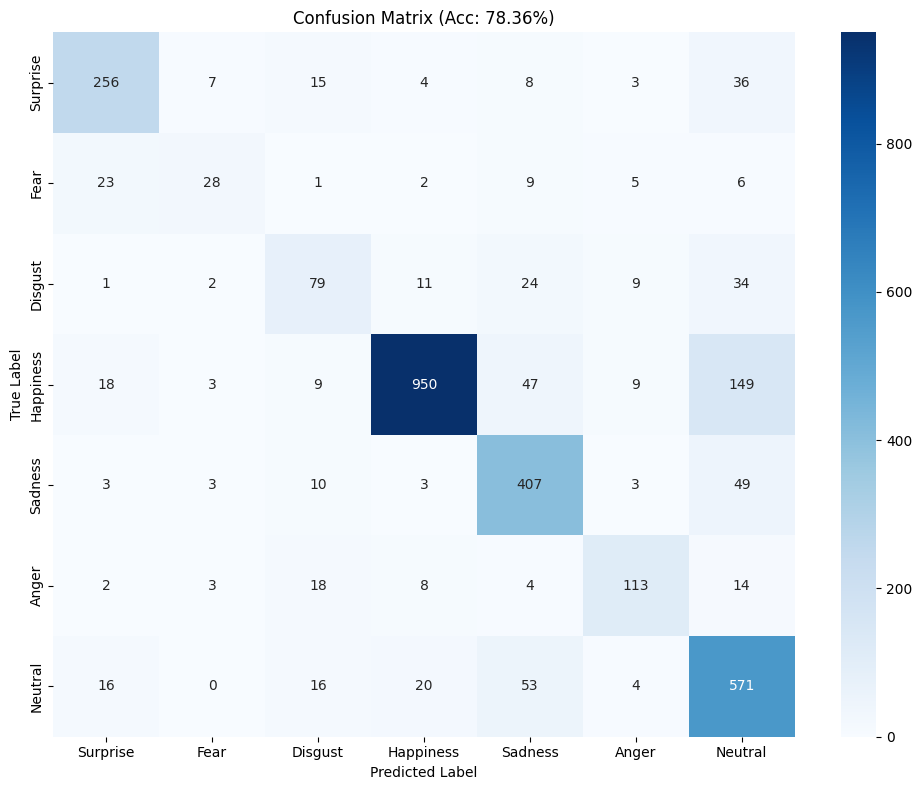

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.15%
Тест с окклюзиями в нижней части лица:   Accuracy = 78.36%
Падение качества:      7.79%


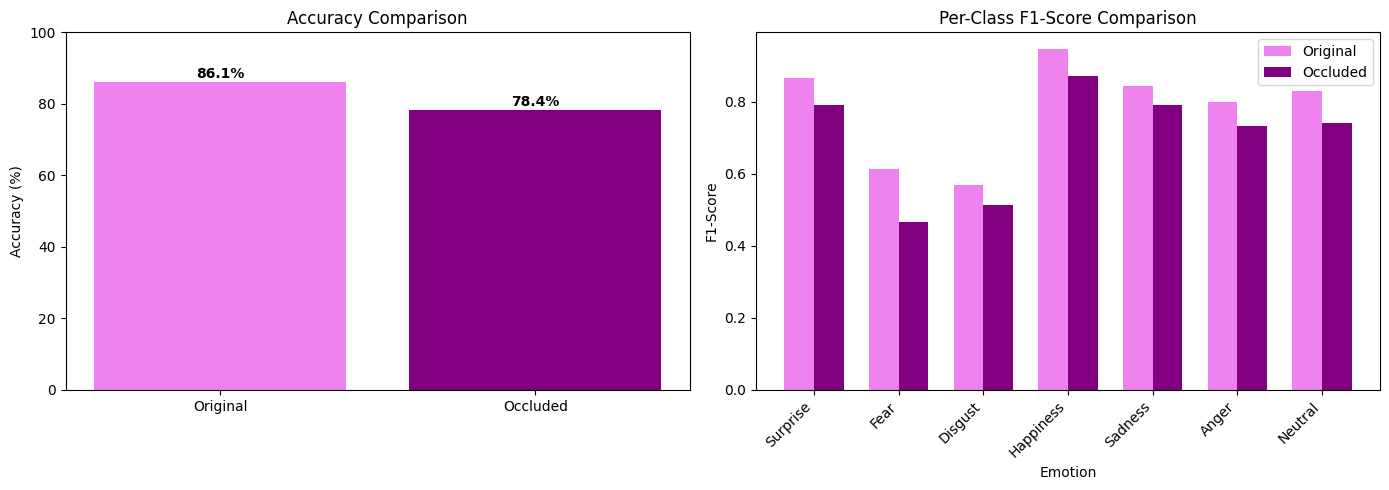

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path


class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        
        weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b2(weights=weights)
        in_features = 1408
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        
    
    def forward(self, x):
        return self.backbone(x)


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue
        
        print(f"Загружено {len(self.images)} изображений из {self.root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), img_path


def test_on_occluded_dataset(model_path, test_dir, batch_size=32, save_results=True):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")
    
    print(f"\nЗагрузка модели из {model_path}")
    model = EfficientNetEmotion(num_classes=7, pretrained=True).to(device)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Загружена модель с эпохи {checkpoint.get('epoch', '?')}, "
          f"val acc = {checkpoint.get('val_acc', '?'):.2f}%")
    
    model = model.to(device)
    model.eval()
    
    print(f"\nЗагрузка тестовых данных из {test_dir}")

    test_dataset = TestDataset(test_dir)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nТестирование на {len(test_dataset)} изображениях")
    
    all_preds = []
    all_labels = []
    all_paths = []
    
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust',
        3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }
    
    with torch.no_grad():
        for inputs, labels, paths in tqdm(test_loader, desc='Тестирование'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    
    valid_indices = [i for i, l in enumerate(all_labels) if l != -1]
    valid_preds = [all_preds[i] for i in valid_indices]
    valid_labels = [all_labels[i] for i in valid_indices]
    valid_paths = [all_paths[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labels, valid_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average='macro', zero_division=0
    )
    
    print(f"Результаты модели на тесте")
    print(f"Всего изображений: {len(test_dataset)}")
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    
    print(f"\nPer-class metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 48)
    for i in range(7):
        print(f"{emotion_labels[i]:<12} {precision[i]:<12.3f} {recall[i]:<12.3f} {f1[i]:<12.3f}")
    
    cm = confusion_matrix(valid_labels, valid_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title(f'Confusion Matrix (Acc: {accuracy:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()

    plt.show()
    
    if save_results:
        results = {
            'accuracy': accuracy,
            'f1_macro': f1_macro,
            'per_class_precision': precision.tolist(),
            'per_class_recall': recall.tolist(),
            'per_class_f1': f1.tolist(),
            'confusion_matrix': cm.tolist(),
            'predictions': valid_preds,
            'true_labels': valid_labels,
            'image_paths': valid_paths
        }
        
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_f1': f1,
        'confusion_matrix': cm,
        'predictions': valid_preds,
        'true_labels': valid_labels
    }


def compare_results(original_test_path, occluded_test_path, model_path):
    print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА EFFICIENTNET-B2")
    
    print("\n===ОРИГИНАЛЬНЫЙ RAF-DB TEST===\n")
    original_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=original_test_path,
        batch_size=32,
        save_results=False
    )
    
    print("\n===RAF-DB TEST С ОККЛЮЗИЯМИ В НИЖНЕЙ ЧАСТИ ЛИЦА===\n")
    occluded_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=occluded_test_path,
        batch_size=32,
        save_results=True
    )
    
    if original_results and occluded_results:
        print("Сравнительный анализ:")
        print(f"Оригинальный тест:     Accuracy = {original_results['accuracy']:.2f}%")
        print(f"Тест с окклюзиями в нижней части лица:   Accuracy = {occluded_results['accuracy']:.2f}%")
        print(f"Падение качества:      {original_results['accuracy'] - occluded_results['accuracy']:.2f}%")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        ax[0].bar(['Original', 'Occluded'], 
                  [original_results['accuracy'], occluded_results['accuracy']],
                  color=['violet', 'purple'])
        ax[0].set_ylabel('Accuracy (%)')
        ax[0].set_title('Accuracy Comparison')
        ax[0].set_ylim(0, 100)
        for i, v in enumerate([original_results['accuracy'], occluded_results['accuracy']]):
            ax[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        
        x = np.arange(7)
        width = 0.35
        ax[1].bar(x - width/2, original_results['per_class_f1'], width, label='Original', color='violet')
        ax[1].bar(x + width/2, occluded_results['per_class_f1'], width, label='Occluded', color='purple')
        ax[1].set_xlabel('Emotion')
        ax[1].set_ylabel('F1-Score')
        ax[1].set_title('Per-Class F1-Score Comparison')
        ax[1].set_xticks(x)
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        ax[1].set_xticklabels(emotion_labels, rotation=45, ha='right')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    MODEL_PATH = r"C:\Users\Pulse_GL66\Downloads\best_model (15).pth"
    ORIGINAL_TEST_PATH = r"D:\НИР\RAF-DB\DATASET\test"
    OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset_lower"
    
    compare_results(ORIGINAL_TEST_PATH, OCCLUDED_TEST_PATH, MODEL_PATH)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА EFFICIENTNET-B2

===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model (15).pth
  Загружена модель с эпохи 32, val acc = 86.20%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:12<00:00,  7.85it/s]


Результаты модели на тесте
Всего изображений: 3068

Accuracy: 86.15%
Macro F1-Score: 0.7807

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.869        0.863        0.866       
Fear         0.652        0.581        0.614       
Disgust      0.656        0.500        0.567       
Happiness    0.952        0.938        0.945       
Sadness      0.832        0.858        0.844       
Anger        0.814        0.784        0.799       
Neutral      0.798        0.863        0.829       


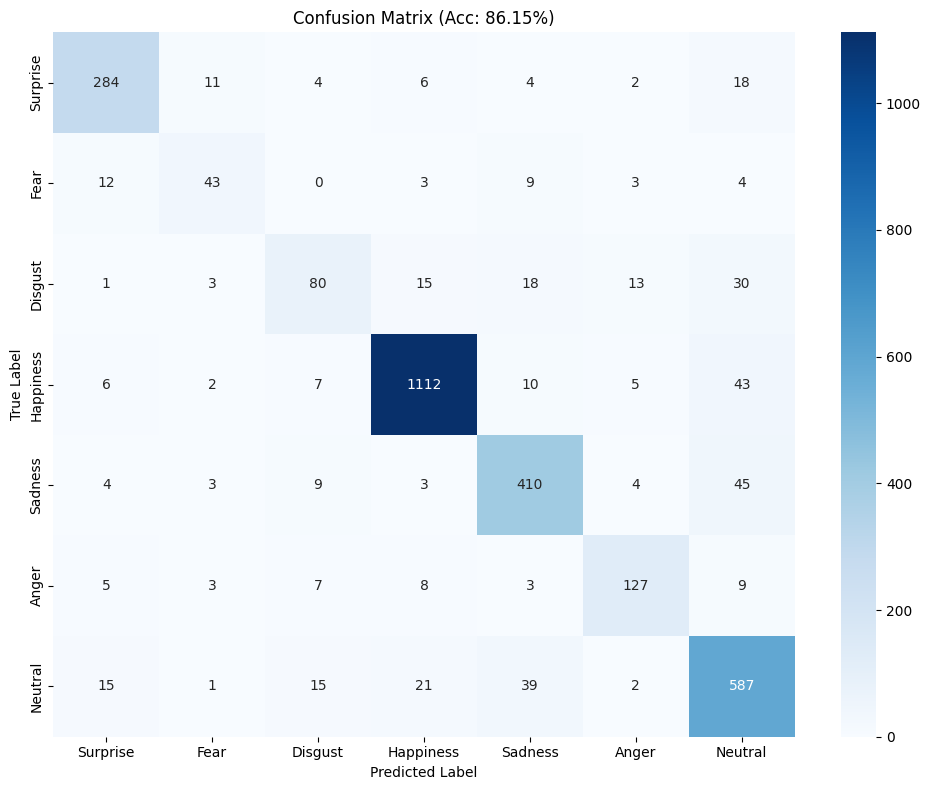


===RAF-DB TEST С ОККЛЮЗИЯМИ В ВЕРХНЕЙ ЧАСТИ ЛИЦА===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model (15).pth
  Загружена модель с эпохи 32, val acc = 86.20%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset_upper
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset_upper

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:30<00:00,  3.14it/s]


Результаты модели на тесте
Всего изображений: 3068

Accuracy: 83.28%
Macro F1-Score: 0.7386

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.854        0.821        0.837       
Fear         0.625        0.473        0.538       
Disgust      0.578        0.463        0.514       
Happiness    0.936        0.922        0.929       
Sadness      0.807        0.780        0.794       
Anger        0.727        0.772        0.749       
Neutral      0.764        0.862        0.810       


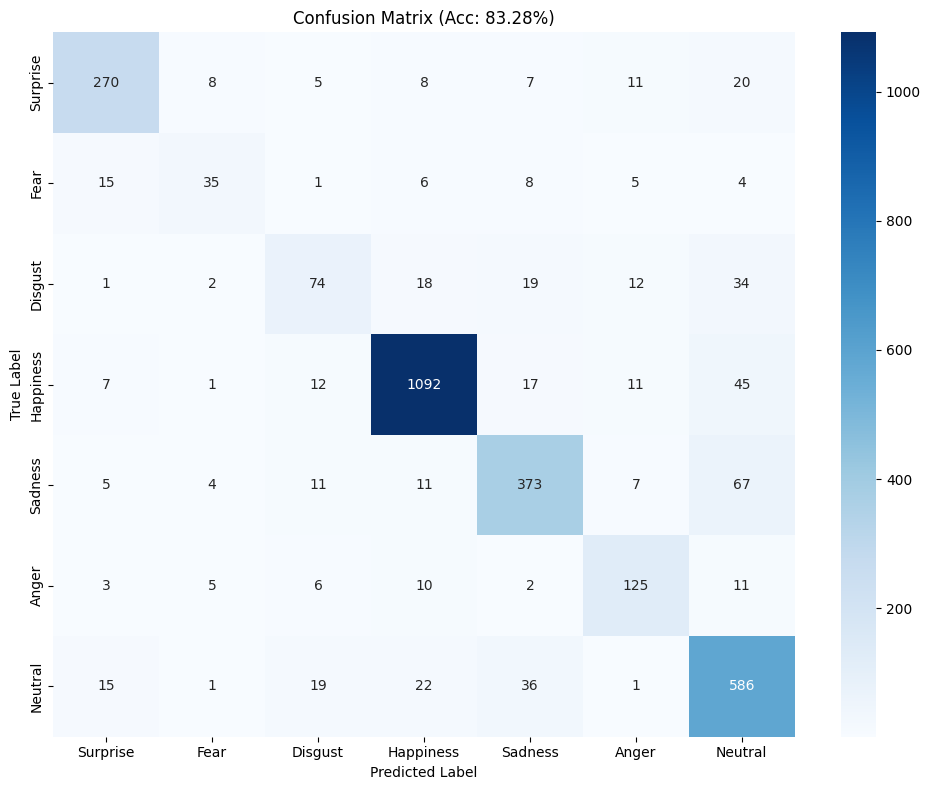

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.15%
Тест с окклюзиями в нижней части лица:   Accuracy = 83.28%
Падение качества:      2.87%


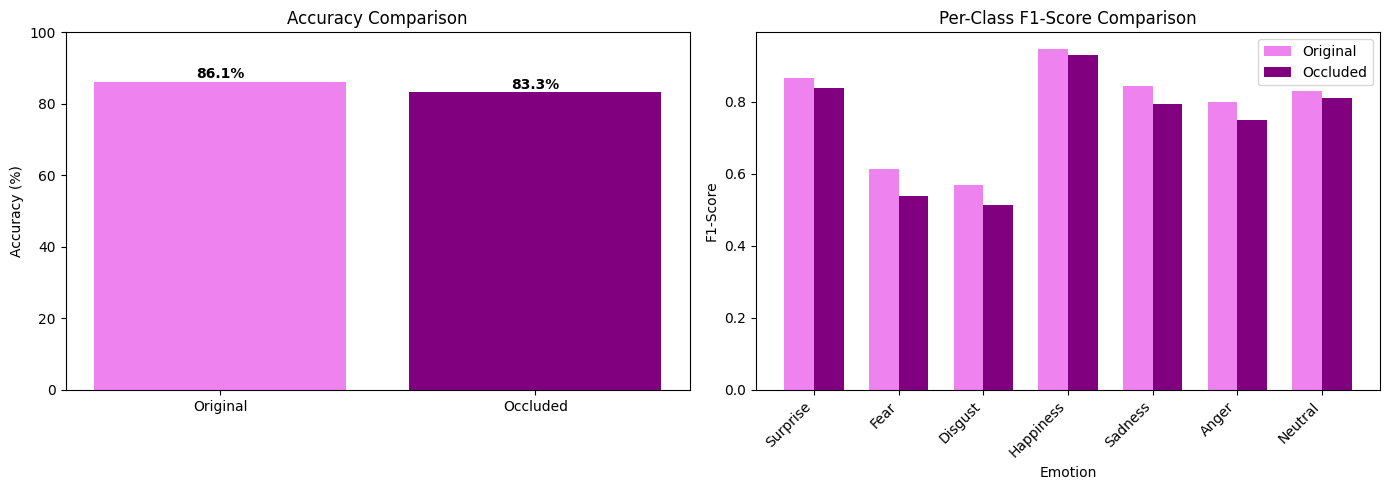

In [ ]:
c


СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА CONVNEXT-TINY


===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth
  Загружена модель с эпохи 31, val acc = 87.51%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:19<00:00,  4.98it/s]



Accuracy: 86.90%
Macro F1-Score: 0.7922

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.837        0.857        0.847       
Fear         0.611        0.595        0.603       
Disgust      0.678        0.631        0.654       
Happiness    0.948        0.949        0.948       
Sadness      0.849        0.858        0.853       
Anger        0.775        0.809        0.792       
Neutral      0.854        0.844        0.849       


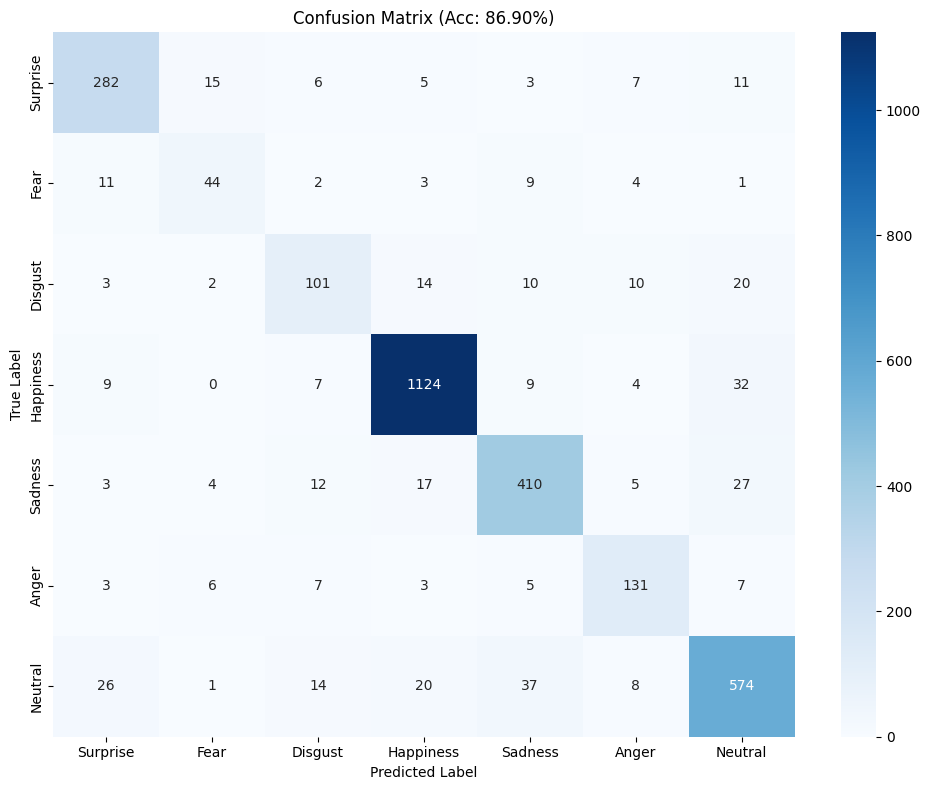


===RAF-DB TEST С ОККЛЮЗИЯМИ===

Устройство: cuda

Загрузка модели из D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth
  Загружена модель с эпохи 31, val acc = 87.51%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:19<00:00,  4.97it/s]



Accuracy: 80.64%
Macro F1-Score: 0.7182

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.758        0.799        0.778       
Fear         0.548        0.459        0.500       
Disgust      0.546        0.556        0.551       
Happiness    0.939        0.878        0.907       
Sadness      0.759        0.831        0.793       
Anger        0.731        0.722        0.727       
Neutral      0.757        0.785        0.771       


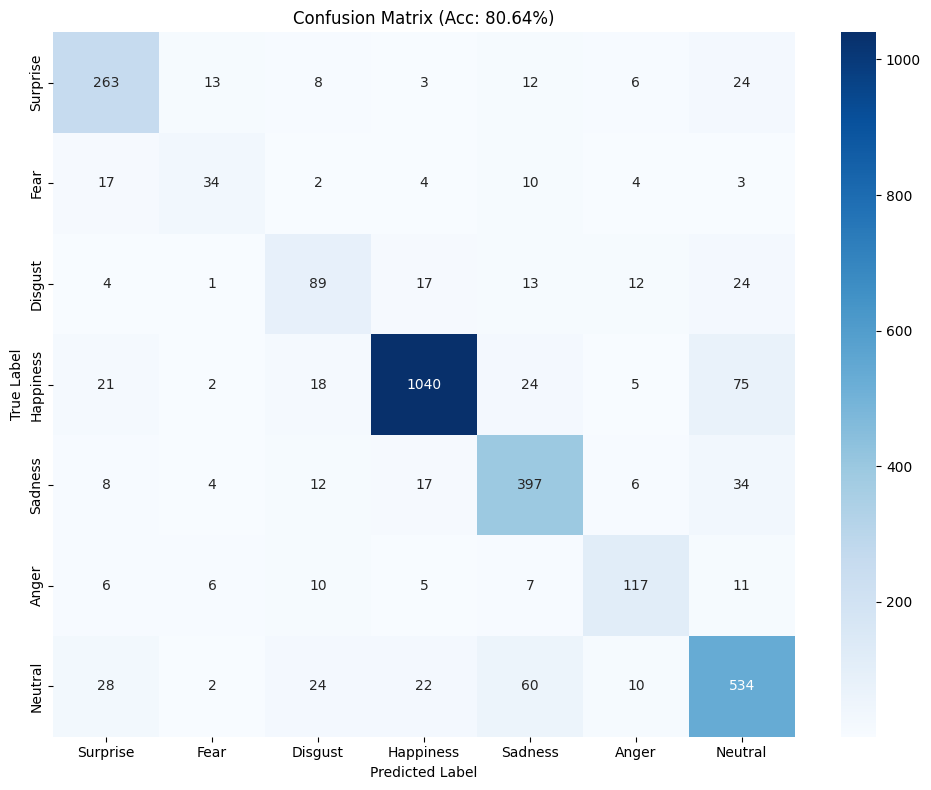

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.90%
Тест с окклюзиями:   Accuracy = 80.64%
Падение качества:      6.26%


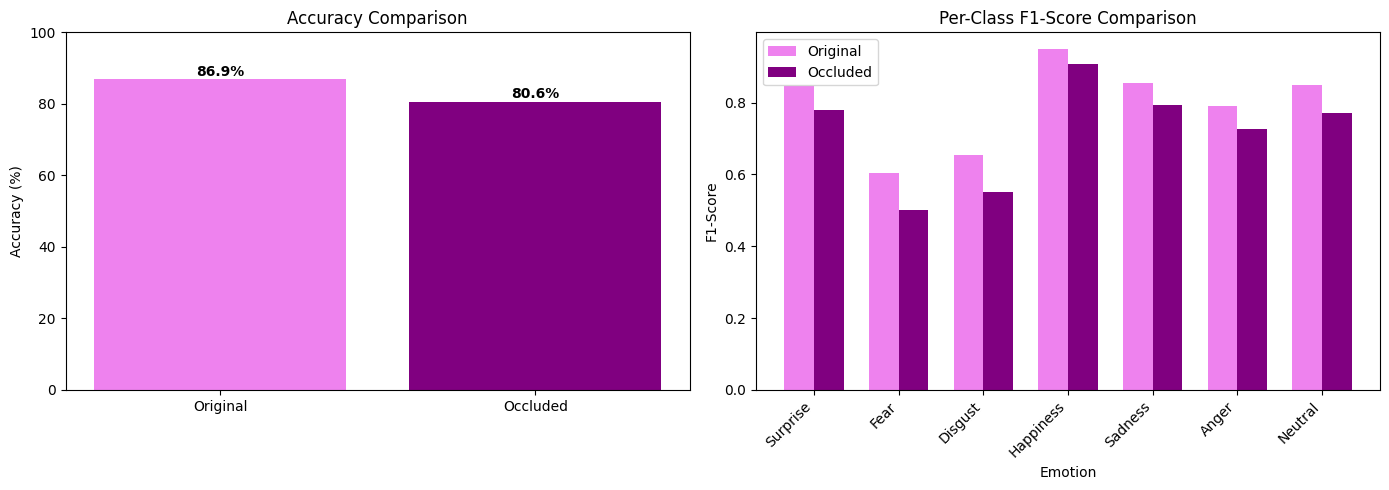

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path



class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.convnext_tiny(weights=weights)

        in_features = 768

        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Dropout(p=0.35),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        return self.backbone(x)


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
    
    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue
        
        print(f"Загружено {len(self.images)} изображений из {self.root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), img_path


def test_on_occluded_dataset(model_path, test_dir, batch_size=32, save_results=True):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")
    
    print(f"\nЗагрузка модели из {model_path}")
    model = ConvNeXtEmotion(num_classes=7, pretrained=True)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Загружена модель с эпохи {checkpoint.get('epoch', '?')}, "
          f"val acc = {checkpoint.get('val_acc', '?'):.2f}%")
    
    model = model.to(device)
    model.eval()
    
    print(f"\nЗагрузка тестовых данных из {test_dir}")

    test_dataset = TestDataset(test_dir)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nТестирование на {len(test_dataset)} изображениях")
    
    all_preds = []
    all_labels = []
    all_paths = []
    
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust',
        3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }
    
    with torch.no_grad():
        for inputs, labels, paths in tqdm(test_loader, desc='Тестирование'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    
    valid_indices = [i for i, l in enumerate(all_labels) if l != -1]
    valid_preds = [all_preds[i] for i in valid_indices]
    valid_labels = [all_labels[i] for i in valid_indices]
    valid_paths = [all_paths[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labels, valid_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average='macro', zero_division=0
    )
    
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    
    print(f"\nPer-class metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 48)
    for i in range(7):
        print(f"{emotion_labels[i]:<12} {precision[i]:<12.3f} {recall[i]:<12.3f} {f1[i]:<12.3f}")
    
    cm = confusion_matrix(valid_labels, valid_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title(f'Confusion Matrix (Acc: {accuracy:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    
    plt.show()
        
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_f1': f1,
        'confusion_matrix': cm,
        'predictions': valid_preds,
        'true_labels': valid_labels
    }


def compare_results(original_test_path, occluded_test_path, model_path):
    print("\nСРАВНЕНИЕ РЕЗУЛЬТАТОВ НА CONVNEXT-TINY\n")
    
    print("\n===ОРИГИНАЛЬНЫЙ RAF-DB TEST===\n")
    original_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=original_test_path,
        batch_size=32,
        save_results=False
    )
    
    print("\n===RAF-DB TEST С ОККЛЮЗИЯМИ===\n")
    occluded_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=occluded_test_path,
        batch_size=32,
        save_results=True
    )
    
    if original_results and occluded_results:
        print("Сравнительный анализ:")
        print(f"Оригинальный тест:     Accuracy = {original_results['accuracy']:.2f}%")
        print(f"Тест с окклюзиями:   Accuracy = {occluded_results['accuracy']:.2f}%")
        print(f"Падение качества:      {original_results['accuracy'] - occluded_results['accuracy']:.2f}%")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        ax[0].bar(['Original', 'Occluded'], 
                  [original_results['accuracy'], occluded_results['accuracy']],
                  color=['violet', 'purple'])
        ax[0].set_ylabel('Accuracy (%)')
        ax[0].set_title('Accuracy Comparison')
        ax[0].set_ylim(0, 100)
        for i, v in enumerate([original_results['accuracy'], occluded_results['accuracy']]):
            ax[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        
        x = np.arange(7)
        width = 0.35
        ax[1].bar(x - width/2, original_results['per_class_f1'], width, label='Original', color='violet')
        ax[1].bar(x + width/2, occluded_results['per_class_f1'], width, label='Occluded', color='purple')
        ax[1].set_xlabel('Emotion')
        ax[1].set_ylabel('F1-Score')
        ax[1].set_title('Per-Class F1-Score Comparison')
        ax[1].set_xticks(x)
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        ax[1].set_xticklabels(emotion_labels, rotation=45, ha='right')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()
        


if __name__ == "__main__":
    MODEL_PATH = r"D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth"
    ORIGINAL_TEST_PATH = r"D:\НИР\RAF-DB\DATASET\test"
    OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset"
    
    compare_results(ORIGINAL_TEST_PATH, OCCLUDED_TEST_PATH, MODEL_PATH)


СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА CONVNEXT-TINY


===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth
  Загружена модель с эпохи 31, val acc = 87.51%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:17<00:00,  5.47it/s]



Accuracy: 86.90%
Macro F1-Score: 0.7922

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.837        0.857        0.847       
Fear         0.611        0.595        0.603       
Disgust      0.678        0.631        0.654       
Happiness    0.948        0.949        0.948       
Sadness      0.849        0.858        0.853       
Anger        0.775        0.809        0.792       
Neutral      0.854        0.844        0.849       


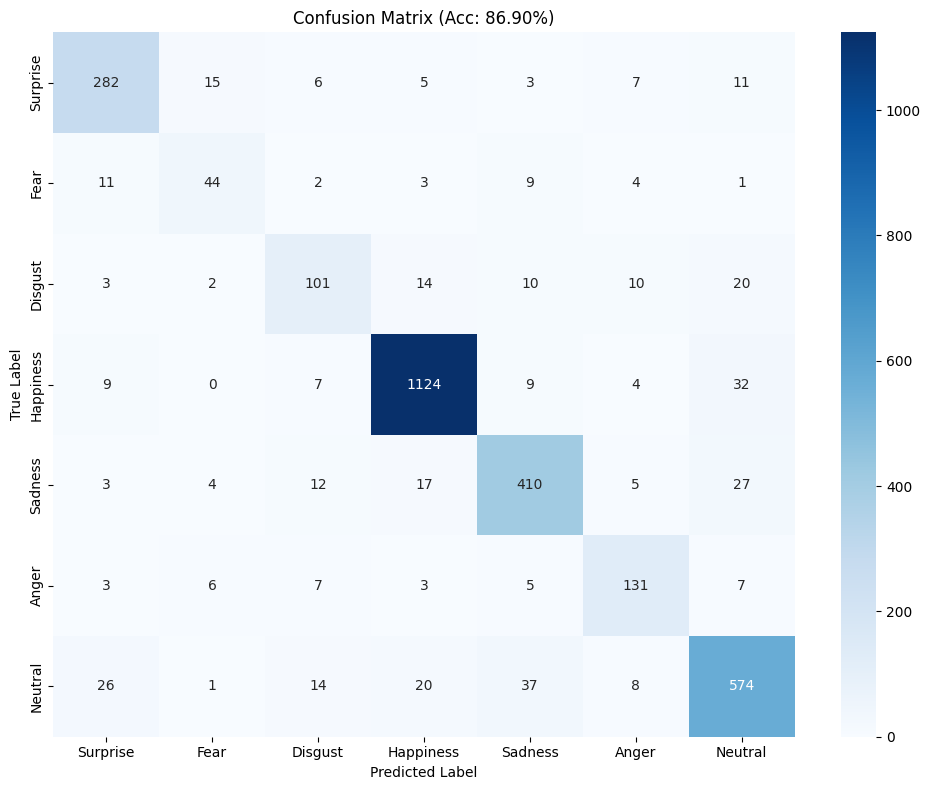


===RAF-DB TEST С ОККЛЮЗИЯМИ НА НИНЖНЕЙ ЧАСТИ ЛИЦА===

Устройство: cuda

Загрузка модели из D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth
  Загружена модель с эпохи 31, val acc = 87.51%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset_lower
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset_lower

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:35<00:00,  2.68it/s]



Accuracy: 79.17%
Macro F1-Score: 0.7149

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.709        0.805        0.754       
Fear         0.562        0.486        0.522       
Disgust      0.528        0.537        0.533       
Happiness    0.950        0.841        0.892       
Sadness      0.751        0.864        0.804       
Anger        0.751        0.784        0.767       
Neutral      0.723        0.743        0.733       


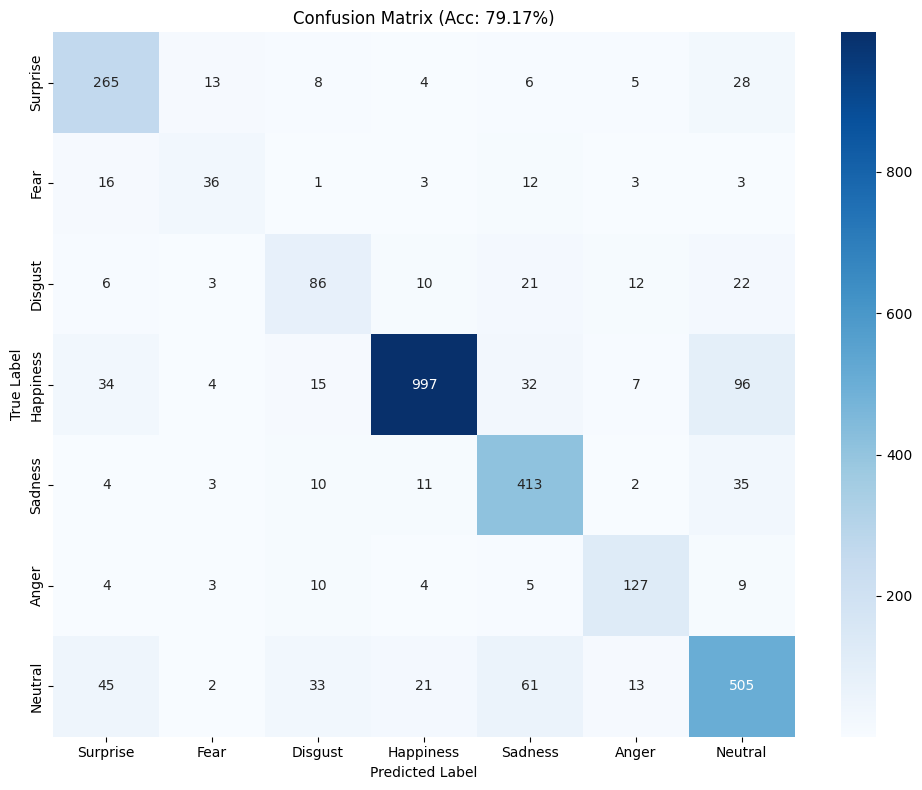

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.90%
Тест с окклюзиями:   Accuracy = 79.17%
Падение качества:      7.72%


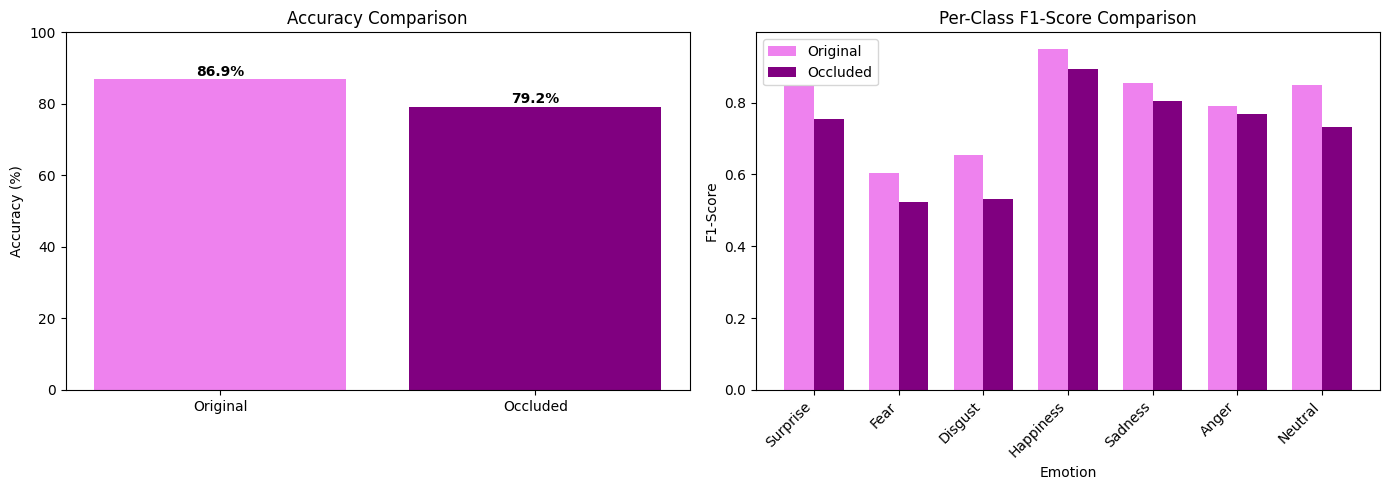

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path



class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.convnext_tiny(weights=weights)

        in_features = 768

        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Dropout(p=0.35),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        return self.backbone(x)


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
    
    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue
        
        print(f"Загружено {len(self.images)} изображений из {self.root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), img_path


def test_on_occluded_dataset(model_path, test_dir, batch_size=32, save_results=True):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")
    
    print(f"\nЗагрузка модели из {model_path}")
    model = ConvNeXtEmotion(num_classes=7, pretrained=True)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Загружена модель с эпохи {checkpoint.get('epoch', '?')}, "
          f"val acc = {checkpoint.get('val_acc', '?'):.2f}%")
    
    model = model.to(device)
    model.eval()
    
    print(f"\nЗагрузка тестовых данных из {test_dir}")

    test_dataset = TestDataset(test_dir)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nТестирование на {len(test_dataset)} изображениях")
    
    all_preds = []
    all_labels = []
    all_paths = []
    
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust',
        3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }
    
    with torch.no_grad():
        for inputs, labels, paths in tqdm(test_loader, desc='Тестирование'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    
    valid_indices = [i for i, l in enumerate(all_labels) if l != -1]
    valid_preds = [all_preds[i] for i in valid_indices]
    valid_labels = [all_labels[i] for i in valid_indices]
    valid_paths = [all_paths[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labels, valid_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average='macro', zero_division=0
    )
    
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    
    print(f"\nPer-class metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 48)
    for i in range(7):
        print(f"{emotion_labels[i]:<12} {precision[i]:<12.3f} {recall[i]:<12.3f} {f1[i]:<12.3f}")
    
    cm = confusion_matrix(valid_labels, valid_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title(f'Confusion Matrix (Acc: {accuracy:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    plt.show()
        
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_f1': f1,
        'confusion_matrix': cm,
        'predictions': valid_preds,
        'true_labels': valid_labels
    }


def compare_results(original_test_path, occluded_test_path, model_path):
    print("\nСРАВНЕНИЕ РЕЗУЛЬТАТОВ НА CONVNEXT-TINY\n")
    
    print("\n===ОРИГИНАЛЬНЫЙ RAF-DB TEST===\n")
    original_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=original_test_path,
        batch_size=32,
        save_results=False
    )
    
    print("\n===RAF-DB TEST С ОККЛЮЗИЯМИ НА НИНЖНЕЙ ЧАСТИ ЛИЦА===\n")
    occluded_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=occluded_test_path,
        batch_size=32,
        save_results=True
    )
    
    if original_results and occluded_results:
        print("Сравнительный анализ:")
        print(f"Оригинальный тест:     Accuracy = {original_results['accuracy']:.2f}%")
        print(f"Тест с окклюзиями:   Accuracy = {occluded_results['accuracy']:.2f}%")
        print(f"Падение качества:      {original_results['accuracy'] - occluded_results['accuracy']:.2f}%")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        ax[0].bar(['Original', 'Occluded'], 
                  [original_results['accuracy'], occluded_results['accuracy']],
                  color=['violet', 'purple'])
        ax[0].set_ylabel('Accuracy (%)')
        ax[0].set_title('Accuracy Comparison')
        ax[0].set_ylim(0, 100)
        for i, v in enumerate([original_results['accuracy'], occluded_results['accuracy']]):
            ax[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        
        x = np.arange(7)
        width = 0.35
        ax[1].bar(x - width/2, original_results['per_class_f1'], width, label='Original', color='violet')
        ax[1].bar(x + width/2, occluded_results['per_class_f1'], width, label='Occluded', color='purple')
        ax[1].set_xlabel('Emotion')
        ax[1].set_ylabel('F1-Score')
        ax[1].set_title('Per-Class F1-Score Comparison')
        ax[1].set_xticks(x)
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        ax[1].set_xticklabels(emotion_labels, rotation=45, ha='right')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    MODEL_PATH = r"D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth"
    ORIGINAL_TEST_PATH = r"D:\НИР\RAF-DB\DATASET\test"
    OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset_lower"
    
    compare_results(ORIGINAL_TEST_PATH, OCCLUDED_TEST_PATH, MODEL_PATH)


СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА CONVNEXT-TINY


===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth
  Загружена модель с эпохи 31, val acc = 87.51%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:17<00:00,  5.42it/s]



Accuracy: 86.90%
Macro F1-Score: 0.7922

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.837        0.857        0.847       
Fear         0.611        0.595        0.603       
Disgust      0.678        0.631        0.654       
Happiness    0.948        0.949        0.948       
Sadness      0.849        0.858        0.853       
Anger        0.775        0.809        0.792       
Neutral      0.854        0.844        0.849       


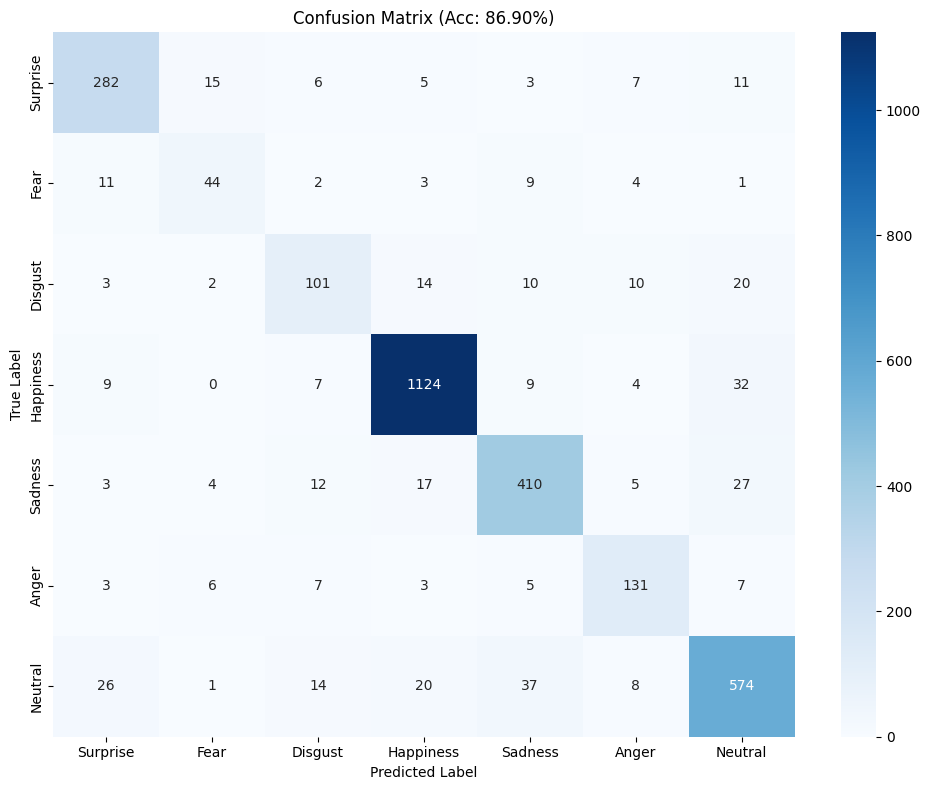


===RAF-DB TEST С ОККЛЮЗИЯМИ НА ВЕРХНЕЙ ЧАСТИ ЛИЦА===

Устройство: cuda

Загрузка модели из D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth
  Загружена модель с эпохи 31, val acc = 87.51%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset_upper
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset_upper

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:35<00:00,  2.74it/s]



Accuracy: 83.77%
Macro F1-Score: 0.7500

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.826        0.836        0.831       
Fear         0.655        0.514        0.576       
Disgust      0.586        0.531        0.557       
Happiness    0.939        0.933        0.936       
Sadness      0.789        0.805        0.797       
Anger        0.714        0.772        0.742       
Neutral      0.805        0.818        0.811       


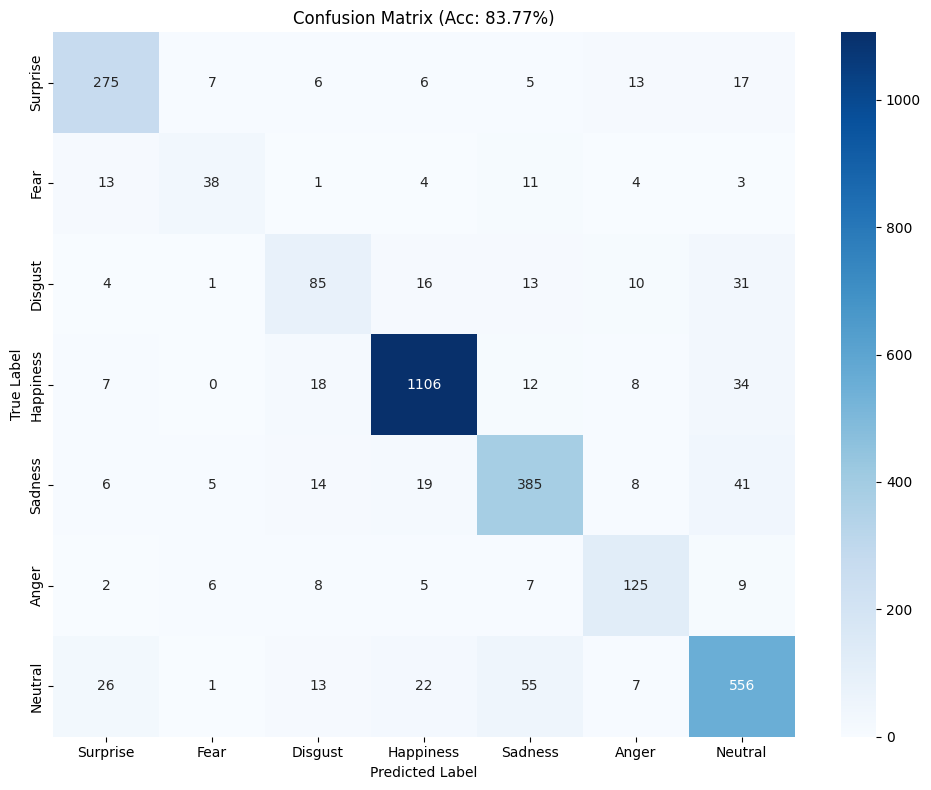

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.90%
Тест с окклюзиями:   Accuracy = 83.77%
Падение качества:      3.13%


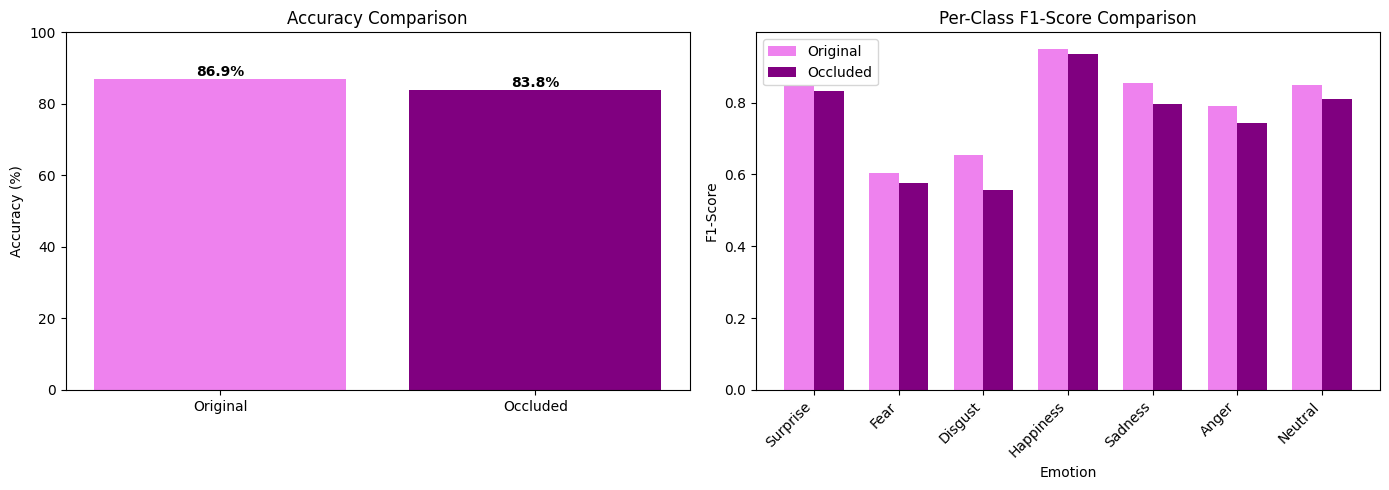

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path



class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.convnext_tiny(weights=weights)

        in_features = 768

        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Dropout(p=0.35),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()
        
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                std=[0.229, 0.224, 0.225])
        ])
    
    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue
        
        print(f"Загружено {len(self.images)} изображений из {self.root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), img_path


def test_on_occluded_dataset(model_path, test_dir, batch_size=32, save_results=True):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")
    
    print(f"\nЗагрузка модели из {model_path}")
    model = ConvNeXtEmotion(num_classes=7, pretrained=True)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Загружена модель с эпохи {checkpoint.get('epoch', '?')}, "
          f"val acc = {checkpoint.get('val_acc', '?'):.2f}%")
    
    model = model.to(device)
    model.eval()
    
    print(f"\nЗагрузка тестовых данных из {test_dir}")

    test_dataset = TestDataset(test_dir)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nТестирование на {len(test_dataset)} изображениях")
    
    all_preds = []
    all_labels = []
    all_paths = []
    
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust',
        3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }
    
    with torch.no_grad():
        for inputs, labels, paths in tqdm(test_loader, desc='Тестирование'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    
    valid_indices = [i for i, l in enumerate(all_labels) if l != -1]
    valid_preds = [all_preds[i] for i in valid_indices]
    valid_labels = [all_labels[i] for i in valid_indices]
    valid_paths = [all_paths[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labels, valid_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average='macro', zero_division=0
    )
    
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    
    print(f"\nPer-class metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 48)
    for i in range(7):
        print(f"{emotion_labels[i]:<12} {precision[i]:<12.3f} {recall[i]:<12.3f} {f1[i]:<12.3f}")
    
    cm = confusion_matrix(valid_labels, valid_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title(f'Confusion Matrix (Acc: {accuracy:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    plt.show()
        
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_f1': f1,
        'confusion_matrix': cm,
        'predictions': valid_preds,
        'true_labels': valid_labels
    }


def compare_results(original_test_path, occluded_test_path, model_path):
    print("\nСРАВНЕНИЕ РЕЗУЛЬТАТОВ НА CONVNEXT-TINY\n")
    
    print("\n===ОРИГИНАЛЬНЫЙ RAF-DB TEST===\n")
    original_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=original_test_path,
        batch_size=32,
        save_results=False
    )
    
    print("\n===RAF-DB TEST С ОККЛЮЗИЯМИ НА ВЕРХНЕЙ ЧАСТИ ЛИЦА===\n")
    occluded_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=occluded_test_path,
        batch_size=32,
        save_results=True
    )
    
    if original_results and occluded_results:
        print("Сравнительный анализ:")
        print(f"Оригинальный тест:     Accuracy = {original_results['accuracy']:.2f}%")
        print(f"Тест с окклюзиями:   Accuracy = {occluded_results['accuracy']:.2f}%")
        print(f"Падение качества:      {original_results['accuracy'] - occluded_results['accuracy']:.2f}%")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        ax[0].bar(['Original', 'Occluded'], 
                  [original_results['accuracy'], occluded_results['accuracy']],
                  color=['violet', 'purple'])
        ax[0].set_ylabel('Accuracy (%)')
        ax[0].set_title('Accuracy Comparison')
        ax[0].set_ylim(0, 100)
        for i, v in enumerate([original_results['accuracy'], occluded_results['accuracy']]):
            ax[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        
        x = np.arange(7)
        width = 0.35
        ax[1].bar(x - width/2, original_results['per_class_f1'], width, label='Original', color='violet')
        ax[1].bar(x + width/2, occluded_results['per_class_f1'], width, label='Occluded', color='purple')
        ax[1].set_xlabel('Emotion')
        ax[1].set_ylabel('F1-Score')
        ax[1].set_title('Per-Class F1-Score Comparison')
        ax[1].set_xticks(x)
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        ax[1].set_xticklabels(emotion_labels, rotation=45, ha='right')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    MODEL_PATH = r"D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth"
    ORIGINAL_TEST_PATH = r"D:\НИР\RAF-DB\DATASET\test"
    OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset_upper"
    
    compare_results(ORIGINAL_TEST_PATH, OCCLUDED_TEST_PATH, MODEL_PATH)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА ViT-SMALL/16

===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model(1).pth
  Загружена модель с эпохи 38, val acc = 86.96%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:15<00:00,  6.03it/s]



Accuracy: 86.64%
Macro F1-Score: 0.7859

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.845        0.878        0.861       
Fear         0.638        0.500        0.561       
Disgust      0.699        0.581        0.635       
Happiness    0.956        0.932        0.944       
Sadness      0.830        0.866        0.847       
Anger        0.818        0.802        0.810       
Neutral      0.819        0.869        0.843       


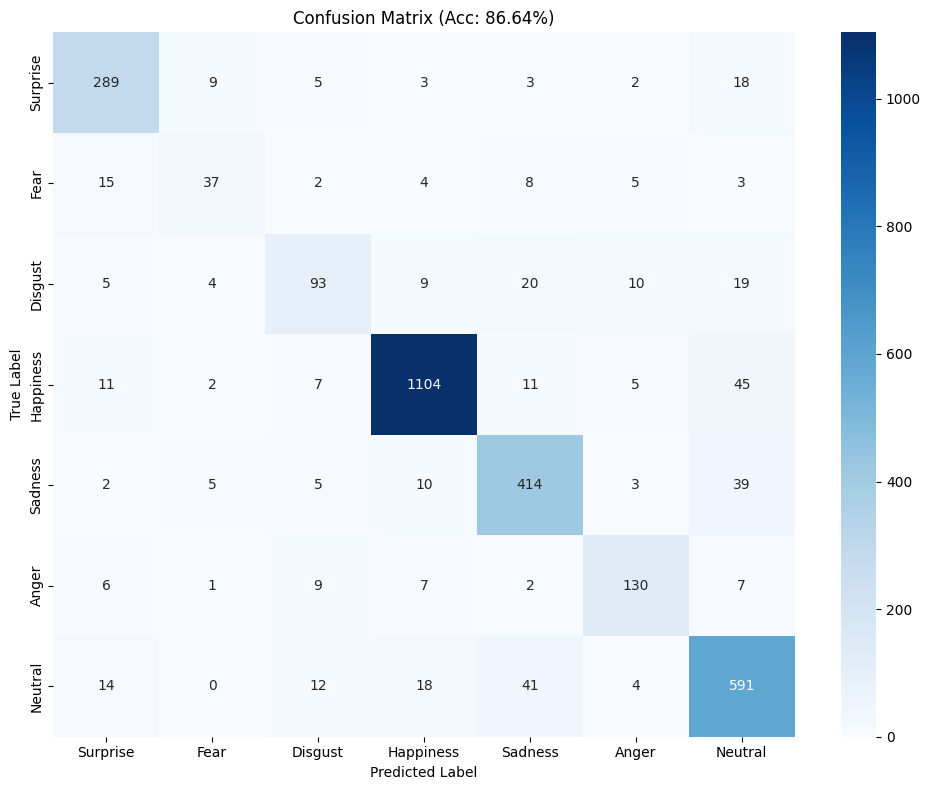


===RAF-DB TEST С ОККЛЮЗИЯМИ===
Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model(1).pth
  Загружена модель с эпохи 38, val acc = 86.96%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:15<00:00,  6.08it/s]



Accuracy: 79.86%
Macro F1-Score: 0.7051

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.793        0.757        0.774       
Fear         0.617        0.392        0.479       
Disgust      0.594        0.494        0.539       
Happiness    0.932        0.874        0.902       
Sadness      0.815        0.736        0.774       
Anger        0.754        0.660        0.704       
Neutral      0.673        0.879        0.762       


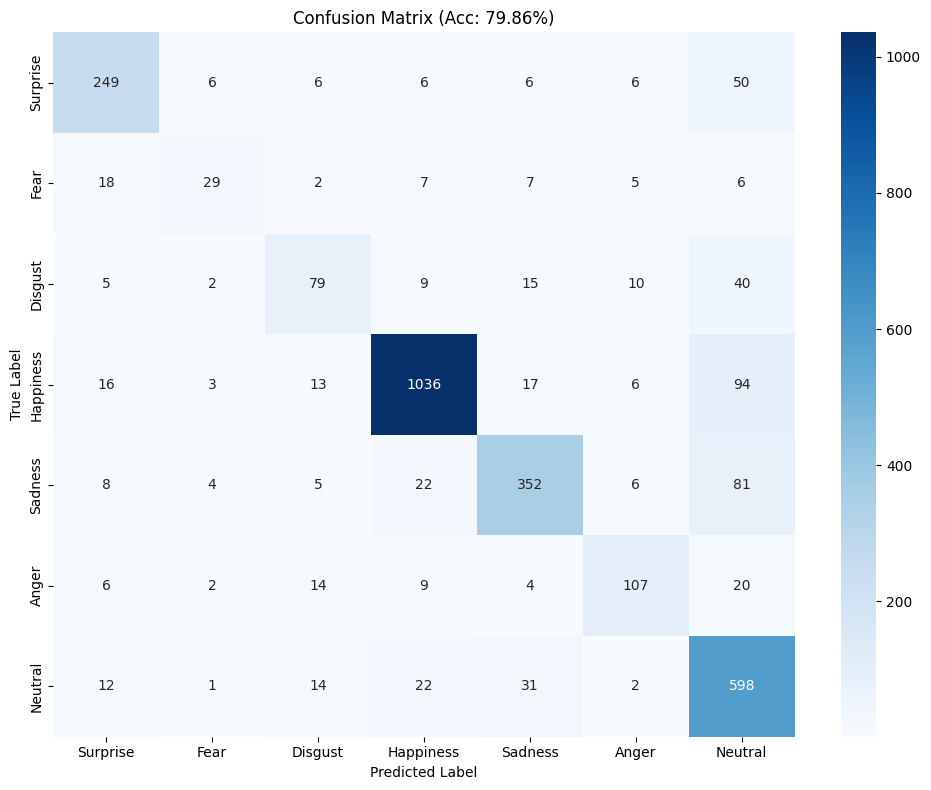

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.64%
Тест с окклюзиями:   Accuracy = 79.86%
Падение качества:      6.78%


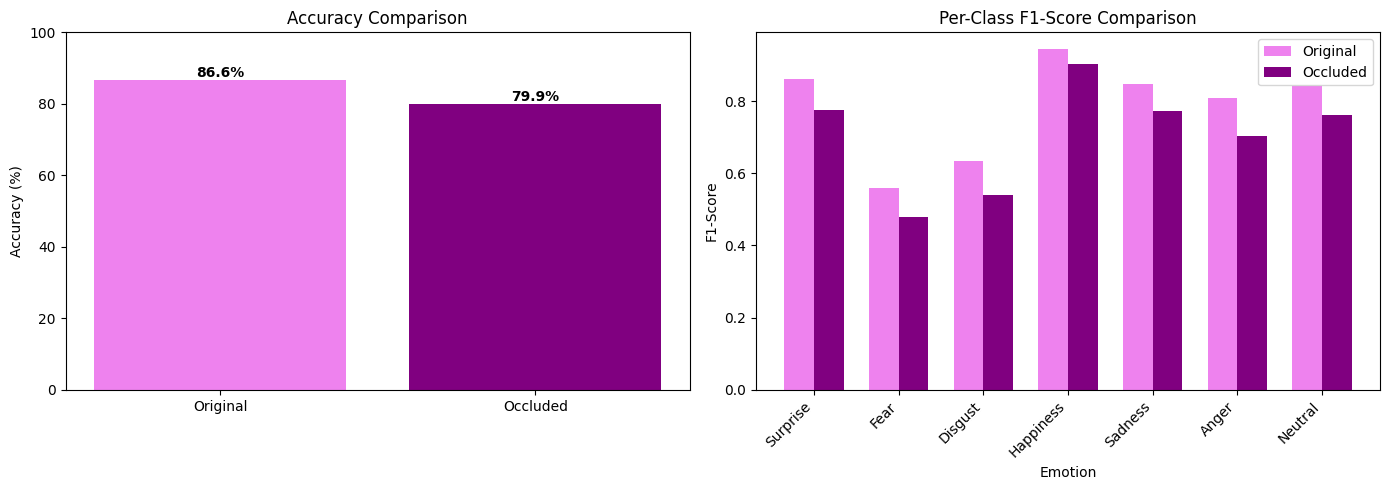

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
import os
from PIL import Image
from pathlib import Path
import timm

warnings.filterwarnings('ignore')


class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )

    def forward(self, x):
        return self.backbone(x)


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue
        
        print(f"Загружено {len(self.images)} изображений из {self.root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), img_path


def test_on_occluded_dataset(model_path, test_dir, batch_size=32, save_results=True):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")
    
    print(f"\nЗагрузка модели из {model_path}")
    model = ViTEmotion(num_classes=7, pretrained=True)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Загружена модель с эпохи {checkpoint.get('epoch', '?')}, "
          f"val acc = {checkpoint.get('val_acc', '?'):.2f}%")
    
    model = model.to(device)
    model.eval()
    
    print(f"\nЗагрузка тестовых данных из {test_dir}")

    test_dataset = TestDataset(test_dir)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nТестирование на {len(test_dataset)} изображениях")
    
    all_preds = []
    all_labels = []
    all_paths = []
    
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust',
        3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }
    
    with torch.no_grad():
        for inputs, labels, paths in tqdm(test_loader, desc='Тестирование'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    
    valid_indices = [i for i, l in enumerate(all_labels) if l != -1]
    valid_preds = [all_preds[i] for i in valid_indices]
    valid_labels = [all_labels[i] for i in valid_indices]
    valid_paths = [all_paths[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labels, valid_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average='macro', zero_division=0
    )
    
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    
    print(f"\nPer-class metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 48)
    for i in range(7):
        print(f"{emotion_labels[i]:<12} {precision[i]:<12.3f} {recall[i]:<12.3f} {f1[i]:<12.3f}")
    
    cm = confusion_matrix(valid_labels, valid_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title(f'Confusion Matrix (Acc: {accuracy:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    
    plt.show()
    
    if save_results:
        results = {
            'accuracy': accuracy,
            'f1_macro': f1_macro,
            'per_class_precision': precision.tolist(),
            'per_class_recall': recall.tolist(),
            'per_class_f1': f1.tolist(),
            'confusion_matrix': cm.tolist(),
            'predictions': valid_preds,
            'true_labels': valid_labels,
            'image_paths': valid_paths
        }
        
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_f1': f1,
        'confusion_matrix': cm,
        'predictions': valid_preds,
        'true_labels': valid_labels
    }


def compare_results(original_test_path, occluded_test_path, model_path):
    print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА ViT-SMALL/16")
    
    print("\n===ОРИГИНАЛЬНЫЙ RAF-DB TEST===\n")
    original_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=original_test_path,
        batch_size=32,
        save_results=False
    )
    
    print("\n===RAF-DB TEST С ОККЛЮЗИЯМИ===")
    occluded_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=occluded_test_path,
        batch_size=32,
        save_results=True
    )
    
    if original_results and occluded_results:
        print("Сравнительный анализ:")
        print(f"Оригинальный тест:     Accuracy = {original_results['accuracy']:.2f}%")
        print(f"Тест с окклюзиями:   Accuracy = {occluded_results['accuracy']:.2f}%")
        print(f"Падение качества:      {original_results['accuracy'] - occluded_results['accuracy']:.2f}%")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        ax[0].bar(['Original', 'Occluded'], 
                  [original_results['accuracy'], occluded_results['accuracy']],
                  color=['violet', 'purple'])
        ax[0].set_ylabel('Accuracy (%)')
        ax[0].set_title('Accuracy Comparison')
        ax[0].set_ylim(0, 100)
        for i, v in enumerate([original_results['accuracy'], occluded_results['accuracy']]):
            ax[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        
        x = np.arange(7)
        width = 0.35
        ax[1].bar(x - width/2, original_results['per_class_f1'], width, label='Original', color='violet')
        ax[1].bar(x + width/2, occluded_results['per_class_f1'], width, label='Occluded', color='purple')
        ax[1].set_xlabel('Emotion')
        ax[1].set_ylabel('F1-Score')
        ax[1].set_title('Per-Class F1-Score Comparison')
        ax[1].set_xticks(x)
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        ax[1].set_xticklabels(emotion_labels, rotation=45, ha='right')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    MODEL_PATH = r"C:\Users\Pulse_GL66\Downloads\best_model(1).pth"
    ORIGINAL_TEST_PATH = r"D:\НИР\RAF-DB\DATASET\test"
    OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset"
    
    compare_results(ORIGINAL_TEST_PATH, OCCLUDED_TEST_PATH, MODEL_PATH)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА ViT-SMALL/16

===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model(1).pth
  Загружена модель с эпохи 38, val acc = 86.96%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:16<00:00,  5.98it/s]



Accuracy: 86.64%
Macro F1-Score: 0.7859

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.845        0.878        0.861       
Fear         0.638        0.500        0.561       
Disgust      0.699        0.581        0.635       
Happiness    0.956        0.932        0.944       
Sadness      0.830        0.866        0.847       
Anger        0.818        0.802        0.810       
Neutral      0.819        0.869        0.843       


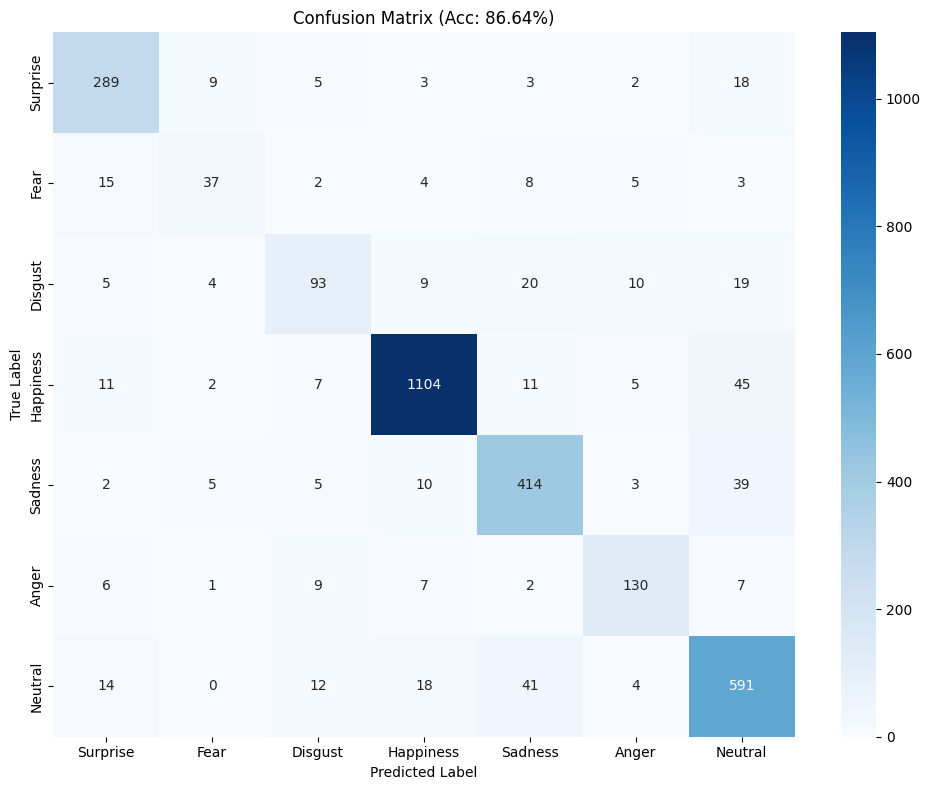


===RAF-DB TEST С ОККЛЮЗИЯМИ В НИЖНЕЙ ЧАСТИ ЛИЦА===
Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model(1).pth
  Загружена модель с эпохи 38, val acc = 86.96%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset_lower
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset_lower

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:16<00:00,  5.94it/s]



Accuracy: 78.91%
Macro F1-Score: 0.6900

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.749        0.769        0.759       
Fear         0.561        0.311        0.400       
Disgust      0.567        0.450        0.502       
Happiness    0.938        0.842        0.888       
Sadness      0.810        0.793        0.801       
Anger        0.803        0.679        0.736       
Neutral      0.656        0.862        0.745       


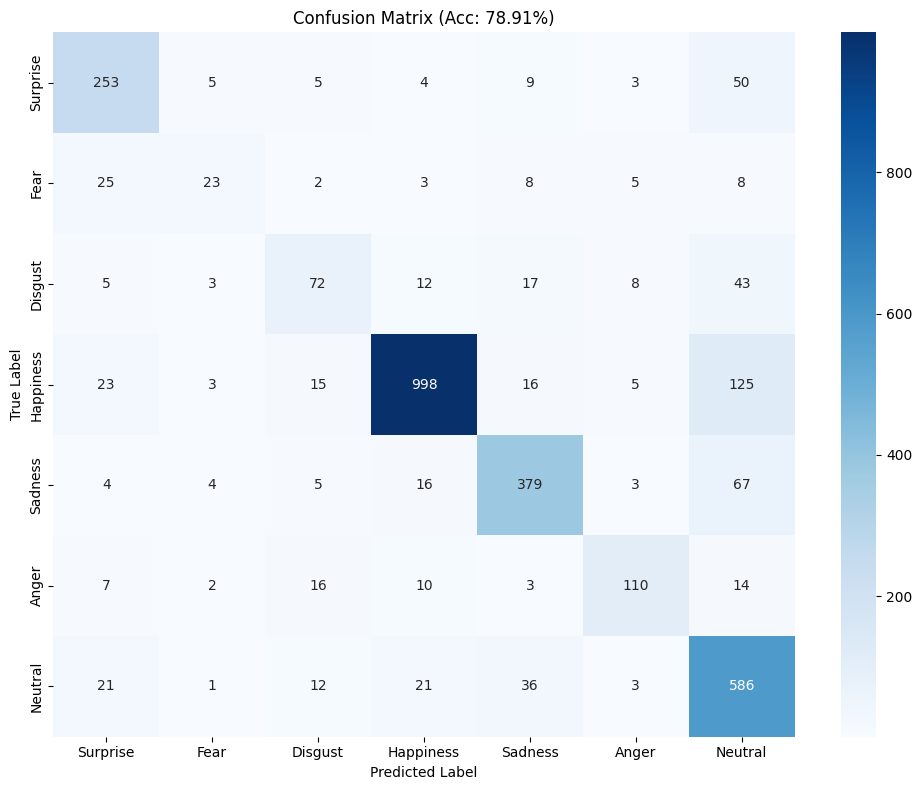

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.64%
Тест с окклюзиями:   Accuracy = 78.91%
Падение качества:      7.72%


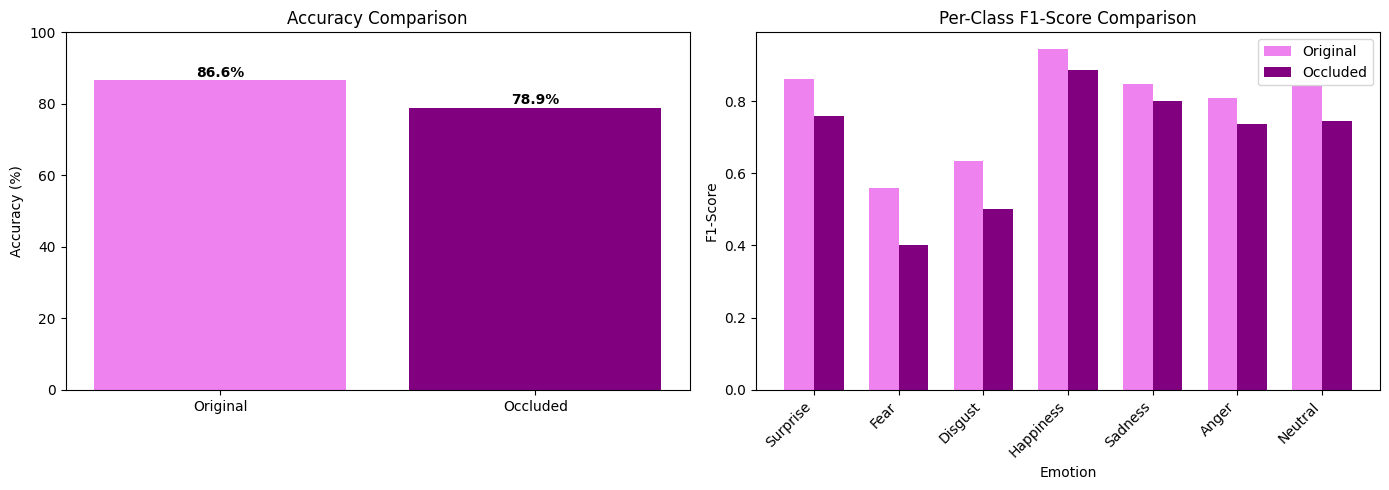

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path
import timm


class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )

    def forward(self, x):
        return self.backbone(x)


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue
        
        print(f"Загружено {len(self.images)} изображений из {self.root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), img_path


def test_on_occluded_dataset(model_path, test_dir, batch_size=32, save_results=True):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")
    
    print(f"\nЗагрузка модели из {model_path}")
    model = ViTEmotion(num_classes=7, pretrained=True)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Загружена модель с эпохи {checkpoint.get('epoch', '?')}, "
          f"val acc = {checkpoint.get('val_acc', '?'):.2f}%")
    
    model = model.to(device)
    model.eval()
    
    print(f"\nЗагрузка тестовых данных из {test_dir}")

    test_dataset = TestDataset(test_dir)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nТестирование на {len(test_dataset)} изображениях")
    
    all_preds = []
    all_labels = []
    all_paths = []
    
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust',
        3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }
    
    with torch.no_grad():
        for inputs, labels, paths in tqdm(test_loader, desc='Тестирование'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    
    valid_indices = [i for i, l in enumerate(all_labels) if l != -1]
    valid_preds = [all_preds[i] for i in valid_indices]
    valid_labels = [all_labels[i] for i in valid_indices]
    valid_paths = [all_paths[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labels, valid_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average='macro', zero_division=0
    )
    
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    
    print(f"\nPer-class metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 48)
    for i in range(7):
        print(f"{emotion_labels[i]:<12} {precision[i]:<12.3f} {recall[i]:<12.3f} {f1[i]:<12.3f}")
    
    cm = confusion_matrix(valid_labels, valid_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title(f'Confusion Matrix (Acc: {accuracy:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    plt.show()
    
        
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_f1': f1,
        'confusion_matrix': cm,
        'predictions': valid_preds,
        'true_labels': valid_labels
    }


def compare_results(original_test_path, occluded_test_path, model_path):
    print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА ViT-SMALL/16")
    
    print("\n===ОРИГИНАЛЬНЫЙ RAF-DB TEST===\n")
    original_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=original_test_path,
        batch_size=32,
        save_results=False
    )
    
    print("\n===RAF-DB TEST С ОККЛЮЗИЯМИ В НИЖНЕЙ ЧАСТИ ЛИЦА===")
    occluded_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=occluded_test_path,
        batch_size=32,
        save_results=True
    )
    
    if original_results and occluded_results:
        print("Сравнительный анализ:")
        print(f"Оригинальный тест:     Accuracy = {original_results['accuracy']:.2f}%")
        print(f"Тест с окклюзиями:   Accuracy = {occluded_results['accuracy']:.2f}%")
        print(f"Падение качества:      {original_results['accuracy'] - occluded_results['accuracy']:.2f}%")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        ax[0].bar(['Original', 'Occluded'], 
                  [original_results['accuracy'], occluded_results['accuracy']],
                  color=['violet', 'purple'])
        ax[0].set_ylabel('Accuracy (%)')
        ax[0].set_title('Accuracy Comparison')
        ax[0].set_ylim(0, 100)
        for i, v in enumerate([original_results['accuracy'], occluded_results['accuracy']]):
            ax[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        
        x = np.arange(7)
        width = 0.35
        ax[1].bar(x - width/2, original_results['per_class_f1'], width, label='Original', color='violet')
        ax[1].bar(x + width/2, occluded_results['per_class_f1'], width, label='Occluded', color='purple')
        ax[1].set_xlabel('Emotion')
        ax[1].set_ylabel('F1-Score')
        ax[1].set_title('Per-Class F1-Score Comparison')
        ax[1].set_xticks(x)
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        ax[1].set_xticklabels(emotion_labels, rotation=45, ha='right')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    MODEL_PATH = r"C:\Users\Pulse_GL66\Downloads\best_model(1).pth"
    ORIGINAL_TEST_PATH = r"D:\НИР\RAF-DB\DATASET\test"
    OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset_lower"
    
    compare_results(ORIGINAL_TEST_PATH, OCCLUDED_TEST_PATH, MODEL_PATH)

СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА ViT-SMALL/16

===ОРИГИНАЛЬНЫЙ RAF-DB TEST===

Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model(1).pth
  Загружена модель с эпохи 38, val acc = 86.96%

Загрузка тестовых данных из D:\НИР\RAF-DB\DATASET\test
Загружено 3068 изображений из D:\НИР\RAF-DB\DATASET\test

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:16<00:00,  5.99it/s]



Accuracy: 86.64%
Macro F1-Score: 0.7859

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.845        0.878        0.861       
Fear         0.638        0.500        0.561       
Disgust      0.699        0.581        0.635       
Happiness    0.956        0.932        0.944       
Sadness      0.830        0.866        0.847       
Anger        0.818        0.802        0.810       
Neutral      0.819        0.869        0.843       


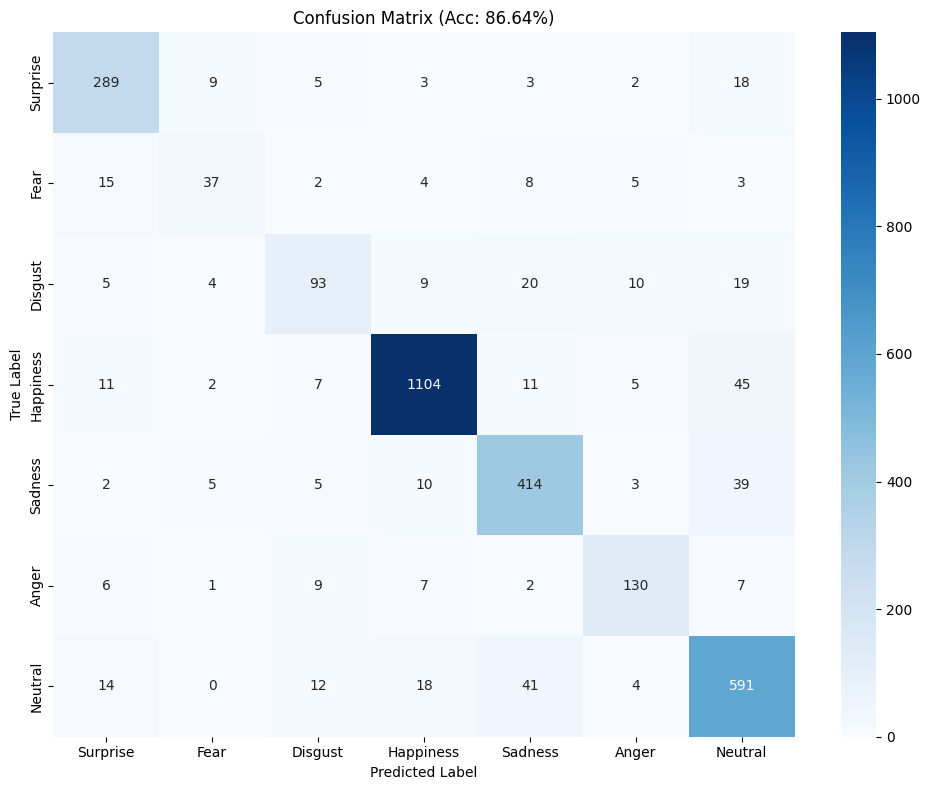


===RAF-DB TEST С ОККЛЮЗИЯМИ В ВЕРХНЕЙ ЧАСТИ ЛИЦА===
Устройство: cuda

Загрузка модели из C:\Users\Pulse_GL66\Downloads\best_model(1).pth
  Загружена модель с эпохи 38, val acc = 86.96%

Загрузка тестовых данных из D:\Occlusions\occluded_test_dataset_upper
Загружено 3068 изображений из D:\Occlusions\occluded_test_dataset_upper

Тестирование на 3068 изображениях


Тестирование: 100%|██████████| 96/96 [00:15<00:00,  6.07it/s]



Accuracy: 82.50%
Macro F1-Score: 0.7365

Per-class metrics:
Class        Precision    Recall       F1-Score    
------------------------------------------------
Surprise     0.858        0.772        0.813       
Fear         0.679        0.486        0.567       
Disgust      0.622        0.525        0.569       
Happiness    0.931        0.935        0.933       
Sadness      0.852        0.676        0.754       
Anger        0.710        0.741        0.725       
Neutral      0.716        0.891        0.794       


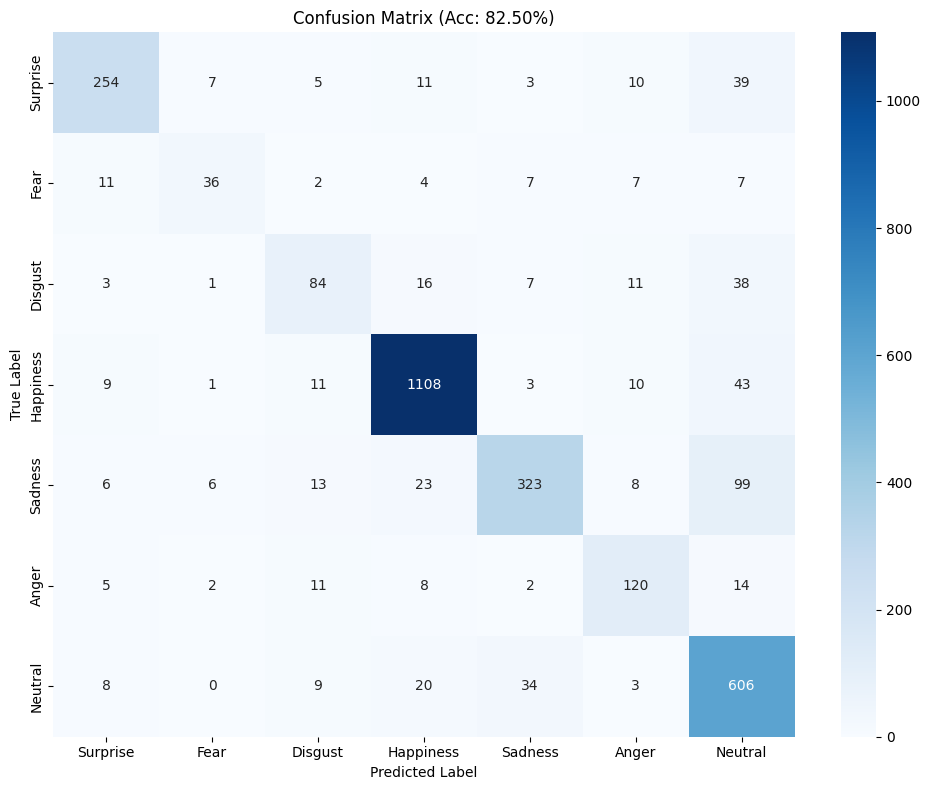

Сравнительный анализ:
Оригинальный тест:     Accuracy = 86.64%
Тест с окклюзиями:   Accuracy = 82.50%
Падение качества:      4.14%


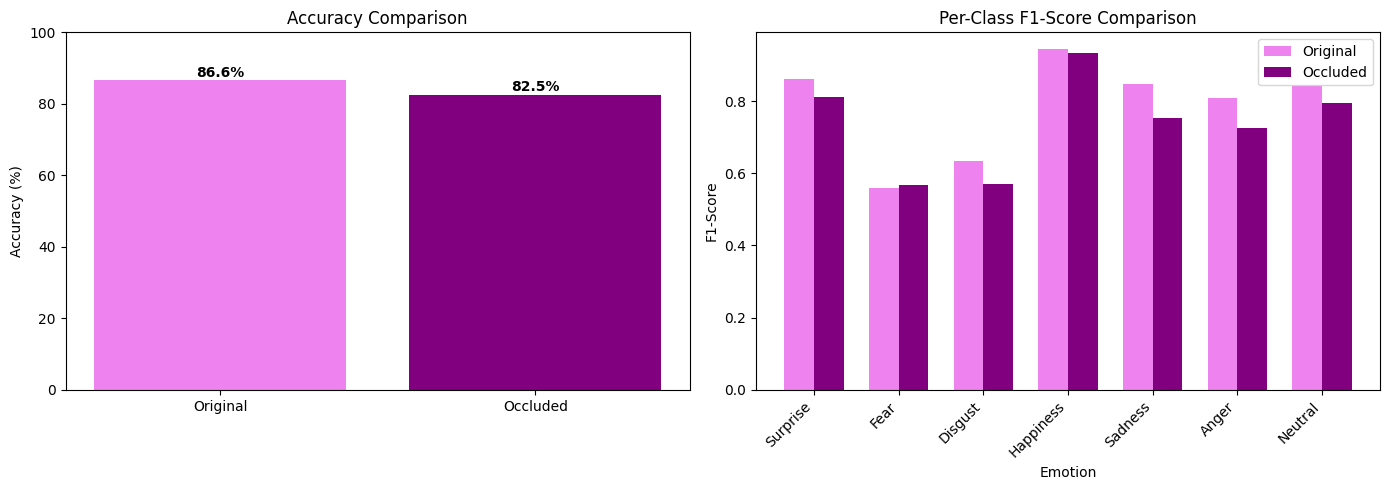

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image
from pathlib import Path
import timm


class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )

    def forward(self, x):
        return self.backbone(x)


class TestDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406],
                               std=[0.229, 0.224, 0.225])
        ])
    
    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue
        
        print(f"Загружено {len(self.images)} изображений из {self.root_dir}")
    
    def __len__(self):
        return len(self.images)
    
    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]
        
        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)
        
        return image, torch.tensor(label, dtype=torch.long), img_path


def test_on_occluded_dataset(model_path, test_dir, batch_size=32, save_results=True):
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Устройство: {device}")
    
    print(f"\nЗагрузка модели из {model_path}")
    model = ViTEmotion(num_classes=7, pretrained=True)
    
    checkpoint = torch.load(model_path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"  Загружена модель с эпохи {checkpoint.get('epoch', '?')}, "
          f"val acc = {checkpoint.get('val_acc', '?'):.2f}%")
    
    model = model.to(device)
    model.eval()
    
    print(f"\nЗагрузка тестовых данных из {test_dir}")

    test_dataset = TestDataset(test_dir)
    
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
    
    print(f"\nТестирование на {len(test_dataset)} изображениях")
    
    all_preds = []
    all_labels = []
    all_paths = []
    
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust',
        3: 'Happiness', 4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }
    
    with torch.no_grad():
        for inputs, labels, paths in tqdm(test_loader, desc='Тестирование'):
            inputs = inputs.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_paths.extend(paths)
    
    valid_indices = [i for i, l in enumerate(all_labels) if l != -1]
    valid_preds = [all_preds[i] for i in valid_indices]
    valid_labels = [all_labels[i] for i in valid_indices]
    valid_paths = [all_paths[i] for i in valid_indices]
    
    accuracy = accuracy_score(valid_labels, valid_preds) * 100
    precision, recall, f1, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average=None, zero_division=0
    )
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        valid_labels, valid_preds, average='macro', zero_division=0
    )
    
    print(f"\nAccuracy: {accuracy:.2f}%")
    print(f"Macro F1-Score: {f1_macro:.4f}")
    
    print(f"\nPer-class metrics:")
    print(f"{'Class':<12} {'Precision':<12} {'Recall':<12} {'F1-Score':<12}")
    print("-" * 48)
    for i in range(7):
        print(f"{emotion_labels[i]:<12} {precision[i]:<12.3f} {recall[i]:<12.3f} {f1[i]:<12.3f}")
    
    cm = confusion_matrix(valid_labels, valid_preds)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=list(emotion_labels.values()),
                yticklabels=list(emotion_labels.values()))
    plt.title(f'Confusion Matrix (Acc: {accuracy:.2f}%)')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    
    plt.show()
    
    
    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'per_class_f1': f1,
        'confusion_matrix': cm,
        'predictions': valid_preds,
        'true_labels': valid_labels
    }


def compare_results(original_test_path, occluded_test_path, model_path):
    print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ НА ViT-SMALL/16")
    
    print("\n===ОРИГИНАЛЬНЫЙ RAF-DB TEST===\n")
    original_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=original_test_path,
        batch_size=32,
        save_results=False
    )
    
    print("\n===RAF-DB TEST С ОККЛЮЗИЯМИ В ВЕРХНЕЙ ЧАСТИ ЛИЦА===")
    occluded_results = test_on_occluded_dataset(
        model_path=model_path,
        test_dir=occluded_test_path,
        batch_size=32,
        save_results=True
    )
    
    if original_results and occluded_results:
        print("Сравнительный анализ:")
        print(f"Оригинальный тест:     Accuracy = {original_results['accuracy']:.2f}%")
        print(f"Тест с окклюзиями:   Accuracy = {occluded_results['accuracy']:.2f}%")
        print(f"Падение качества:      {original_results['accuracy'] - occluded_results['accuracy']:.2f}%")
        
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        ax[0].bar(['Original', 'Occluded'], 
                  [original_results['accuracy'], occluded_results['accuracy']],
                  color=['violet', 'purple'])
        ax[0].set_ylabel('Accuracy (%)')
        ax[0].set_title('Accuracy Comparison')
        ax[0].set_ylim(0, 100)
        for i, v in enumerate([original_results['accuracy'], occluded_results['accuracy']]):
            ax[0].text(i, v + 1, f"{v:.1f}%", ha='center', fontweight='bold')
        
        x = np.arange(7)
        width = 0.35
        ax[1].bar(x - width/2, original_results['per_class_f1'], width, label='Original', color='violet')
        ax[1].bar(x + width/2, occluded_results['per_class_f1'], width, label='Occluded', color='purple')
        ax[1].set_xlabel('Emotion')
        ax[1].set_ylabel('F1-Score')
        ax[1].set_title('Per-Class F1-Score Comparison')
        ax[1].set_xticks(x)
        emotion_labels = ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
        ax[1].set_xticklabels(emotion_labels, rotation=45, ha='right')
        ax[1].legend()
        
        plt.tight_layout()
        plt.show()


if __name__ == "__main__":
    MODEL_PATH = r"C:\Users\Pulse_GL66\Downloads\best_model(1).pth"
    ORIGINAL_TEST_PATH = r"D:\НИР\RAF-DB\DATASET\test"
    OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset_upper"
    
    compare_results(ORIGINAL_TEST_PATH, OCCLUDED_TEST_PATH, MODEL_PATH)

Используется устройство: cuda


Предсказания ViTEmotion: 100%|██████████| 96/96 [00:16<00:00,  5.81it/s]


Размер признакового пространства: 21

Загрузка мета-модели
Мета-модель загружена из D:\Диплом финал\ensemble_results\meta_model.pkl

Сохранение мета-модели
Папка создана: D:\Диплом финал\Occlusions\ensemble_test_with_occlusions
Мета-модель сохранена в D:\Диплом финал\Occlusions\ensemble_test_with_occlusions/meta_model.pkl
РЕЗУЛЬТАТЫ STACKING (с balanced weights)
Test Accuracy:  0.8422
Test Macro F1:  0.7765

Per-class F1-score (Stacking + balanced):
              precision    recall  f1-score   support

    Surprise      0.837     0.830     0.834       329
        Fear      0.712     0.568     0.632        74
     Disgust      0.617     0.644     0.630       160
   Happiness      0.951     0.893     0.921      1185
     Sadness      0.812     0.860     0.835       478
       Anger      0.803     0.753     0.777       162
     Neutral      0.771     0.846     0.806       680

    accuracy                          0.842      3068
   macro avg      0.786     0.770     0.776      3068
weig

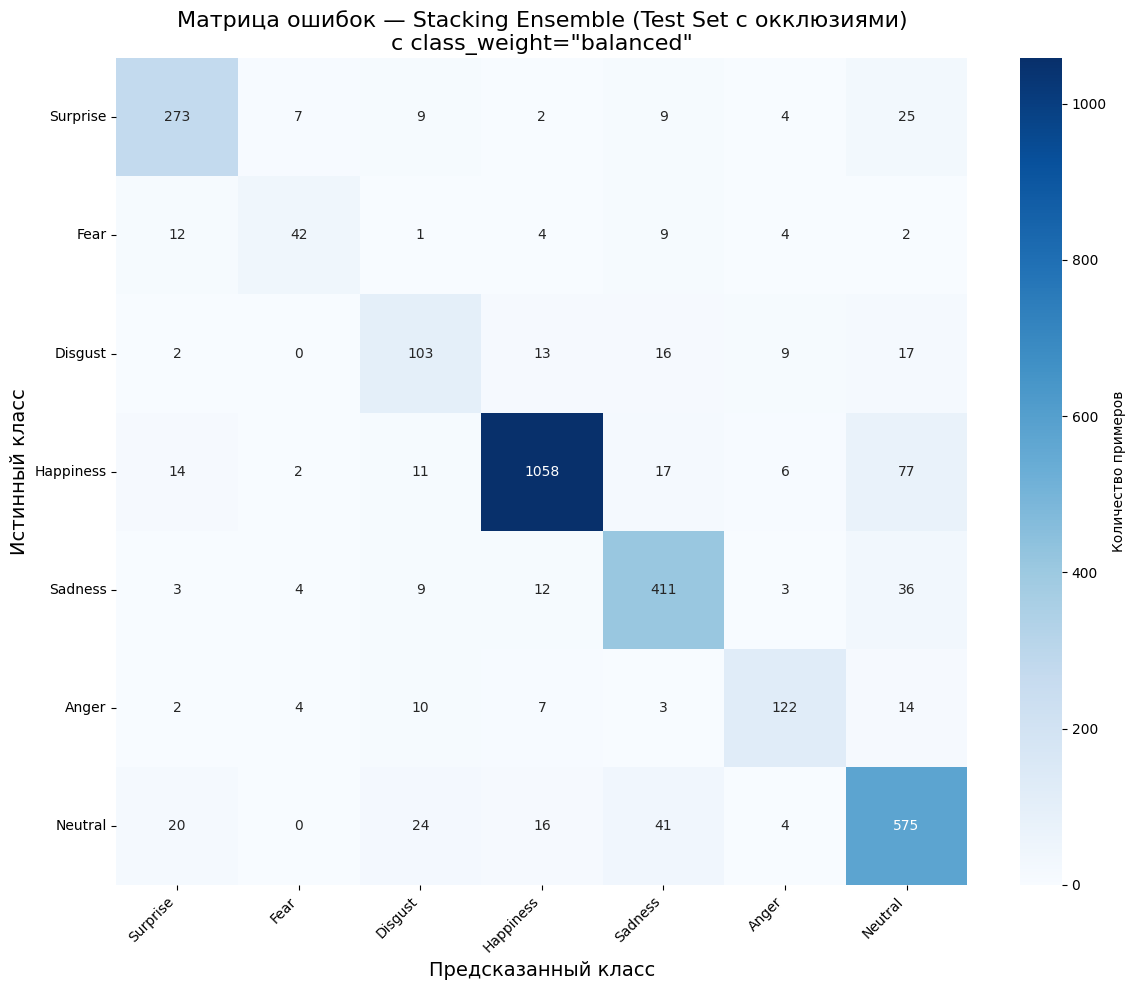

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from tqdm import tqdm
import pickle
from pathlib import Path
from PIL import Image
import timm
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import os

import matplotlib.pyplot as plt
import seaborn as sns


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

RAFDB_ROOT = r"D:\НИР\RAF-DB\DATASET"
SPLITS_PATH = r"D:\НИР\dataset_splits.pkl"
OCCLUDED_TEST_PATH = r"D:\Occlusions\occluded_test_dataset"

PATH_EFF = r"D:\Диплом финал\EfficientNet-B2_model\best_model (15).pth"
PATH_CONV = r"D:\Диплом финал\ConvNeXt-Tiny_model\best_model (17).pth"
PATH_VIT = r"D:\Диплом финал\ViT-Small_16_model\best_model(1).pth"

META_MODEL_PATH = r"D:\Диплом финал\ensemble_results\meta_model.pkl"
RESULTS_DIR = r"D:\Диплом финал\Occlusions\ensemble_test_with_occlusions"

BATCH_SIZE = 32

class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )

    def forward(self, x):
        return self.backbone(x)


class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        
        weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b2(weights=weights)
        in_features = 1408
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        
    
    def forward(self, x):
        return self.backbone(x)


class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.convnext_tiny(weights=weights)

        in_features = 768

        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Dropout(p=0.35),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        return self.backbone(x)


class RAFDBDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except:
                continue

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image = Image.open(self.images[idx]).convert('RGB')
        image = self.transform(image)
        return image, torch.tensor(self.labels[idx], dtype=torch.long)


def create_dataloaders(batch_size=32):

    test_ds = RAFDBDataset(OCCLUDED_TEST_PATH)

    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
        4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }

    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, pin_memory=True)

    return test_loader, emotion_labels


def load_model(model_class, path, num_classes=7):
    model = model_class(num_classes=num_classes).to(device)
    checkpoint = torch.load(path, map_location=device)
    if 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    model.eval()
    return model


model_eff = load_model(EfficientNetEmotion, PATH_EFF)
model_conv = load_model(ConvNeXtEmotion, PATH_CONV)
model_vit = load_model(ViTEmotion, PATH_VIT)

models = [model_eff, model_conv, model_vit]
model_names = ['EfficientNet-B2', 'ConvNeXt-Tiny', 'ViT-Small']


def get_model_probs(model, loader):
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Предсказания {model.__class__.__name__}"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    
    return np.vstack(all_probs), np.concatenate(all_labels)


test_loader, emotion_labels = create_dataloaders(BATCH_SIZE)

val_probs_list = []
test_probs_list = []
val_labels = None
test_labels = None

for model in models:
    test_p, test_l = get_model_probs(model, test_loader)
    
    test_probs_list.append(test_p)
    
    test_labels = test_l

X_test_occluded = np.hstack(test_probs_list)

print(f"Размер признакового пространства: {X_test_occluded.shape[1]}")

print("\nЗагрузка мета-модели")
with open(META_MODEL_PATH, 'rb') as f:
    meta_model = pickle.load(f)
print(f"Мета-модель загружена из {META_MODEL_PATH}")

occluded_pred = meta_model.predict(X_test_occluded)

print("\nСохранение мета-модели")

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Папка создана: {RESULTS_DIR}")

with open(f"{RESULTS_DIR}/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)
print(f"Мета-модель сохранена в {RESULTS_DIR}/meta_model.pkl")

test_pred = meta_model.predict(X_test_occluded)

print("РЕЗУЛЬТАТЫ STACKING (с balanced weights)")

print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking + balanced):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))

print("\n")
print("МАТРИЦА ОШИБОК (Test Set с окклюзиями)")


cm = confusion_matrix(test_labels, test_pred)

print("    " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title('Матрица ошибок — Stacking Ensemble (Test Set с окклюзиями)\nс class_weight="balanced"', fontsize=16)
plt.ylabel('Истинный класс', fontsize=14)
plt.xlabel('Предсказанный класс', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()

In [ ]:
import cv2
import dlib
import numpy as np
import random
import os
import pickle


detector = dlib.get_frontal_face_detector()
predictor_path = r"D:\Occlusions\Landmark_predictor_path\shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(predictor_path)

def load_image(path):
    try:
        with open(path, 'rb') as f:
            data = np.frombuffer(f.read(), dtype=np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except:
        return cv2.imread(path)


def add_upper_occlusion_cover_eyes(img, landmarks):
    h, w = img.shape[:2]
    
    eye_points = [(landmarks.part(i).x, landmarks.part(i).y) for i in range(36, 48)]
    
    eyes_min_x = min(p[0] for p in eye_points)
    eyes_max_x = max(p[0] for p in eye_points)
    eyes_min_y = min(p[1] for p in eye_points)
    eyes_max_y = max(p[1] for p in eye_points)
    
    eyes_width = eyes_max_x - eyes_min_x
    eyes_height = eyes_max_y - eyes_min_y

    occ_width = int(eyes_width * random.uniform(1.2, 2.0))
    occ_height = int(eyes_height * random.uniform(1.6, 4.0))
    
    center_x = (eyes_min_x + eyes_max_x) // 2
    center_y = (eyes_min_y + eyes_max_y) // 2
    x = center_x - occ_width // 2
    y = center_y - occ_height // 2
    
    x += random.randint(-int(occ_width*0.15), int(occ_width*0.15))
    y += random.randint(-int(occ_height*0.1), int(occ_height*0.1))
    
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(w, x + occ_width)
    y2 = min(h, y + occ_height)
    
    if x2 <= x1 or y2 <= y1:
        return img
    
    actual_width = x2 - x1
    actual_height = y2 - y1
    
    color = (random.randint(0, 50), random.randint(0, 50), random.randint(0, 50))
    
    alpha = random.uniform(0.6, 0.95)
    
    shape = random.choice(['rectangle', 'ellipse'])
    
    overlay = img.copy()
    
    if shape == 'rectangle':
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    else:
        center = (x1 + actual_width // 2, y1 + actual_height // 2)
        axes = (actual_width // 2, actual_height // 2)
        cv2.ellipse(overlay, center, axes, 0, 0, 360, color, -1)
    
    result = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    return result


def add_lower_occlusion_cover_mouth(img, landmarks):
    h, w = img.shape[:2]
    
    mouth_points = [(landmarks.part(i).x, landmarks.part(i).y) for i in range(48, 68)]

    mouth_min_x = min(p[0] for p in mouth_points)
    mouth_max_x = max(p[0] for p in mouth_points)
    mouth_min_y = min(p[1] for p in mouth_points)
    mouth_max_y = max(p[1] for p in mouth_points)
    
    mouth_width = mouth_max_x - mouth_min_x
    mouth_height = mouth_max_y - mouth_min_y
    
    occ_width = int(mouth_width * random.uniform(1.2, 2.4))
    occ_height = int(mouth_height * random.uniform(1.2, 2.4))
    
    center_x = (mouth_min_x + mouth_max_x) // 2
    center_y = (mouth_min_y + mouth_max_y) // 2
    x = center_x - occ_width // 2
    y = center_y - occ_height // 2
    
    x += random.randint(-int(occ_width*0.15), int(occ_width*0.15))
    y += random.randint(-int(occ_height*0.1), int(occ_height*0.1))
    
    x1 = max(0, x)
    y1 = max(0, y)
    x2 = min(w, x + occ_width)
    y2 = min(h, y + occ_height)
    
    if x2 <= x1 or y2 <= y1:
        return img
    
    actual_width = x2 - x1
    actual_height = y2 - y1
    
    color_options = [
        (random.randint(150, 220), random.randint(150, 220), random.randint(150, 220)),
        (random.randint(100, 180), random.randint(150, 220), random.randint(200, 240)),
        (random.randint(180, 220), random.randint(180, 220), random.randint(200, 240)),
    ]
    color = random.choice(color_options)
    
    alpha = random.uniform(0.7, 0.95)

    shape = random.choice(['rectangle', 'ellipse'])
    
    overlay = img.copy()
    
    if shape == 'rectangle':
        cv2.rectangle(overlay, (x1, y1), (x2, y2), color, -1)
    else:
        center = (x1 + actual_width // 2, y1 + actual_height // 2)
        axes = (actual_width // 2, actual_height // 2)
        cv2.ellipse(overlay, center, axes, 0, 0, 360, color, -1)
    
    result = cv2.addWeighted(overlay, alpha, img, 1 - alpha, 0)
    return result


def create_occluded_dataset_with_splits(root_dir, splits_path, output_dir_train_occluded, 
                                         output_dir_val_original, occlusion_ratio=0.5):
    with open(splits_path, 'rb') as f:
        splits = pickle.load(f)
    
    train_indices = splits['train_indices']
    val_indices = splits['val_indices']
    
    train_dir = Path(root_dir) / 'train'
    
    all_images = []
    image_to_idx = {}
    idx_to_path = {}
    
    idx = 0
    for class_folder in sorted(train_dir.iterdir()):
        if not class_folder.is_dir():
            continue
        class_idx = int(class_folder.name)
        if class_idx not in range(1, 8):
            continue
        for img_path in class_folder.glob('*.[jp][pn]g'):
            all_images.append(str(img_path))
            image_to_idx[str(img_path)] = idx
            idx_to_path[idx] = str(img_path)
            idx += 1
    
    print(f"Всего изображений в train: {len(all_images)}")
    print(f"Train индексов из split: {len(train_indices)}")
    print(f"Val индексов из split: {len(val_indices)}")
    
    os.makedirs(output_dir_train_occluded, exist_ok=True)
    os.makedirs(output_dir_val_original, exist_ok=True)
    
    for class_folder in train_dir.iterdir():
        if class_folder.is_dir():
            os.makedirs(Path(output_dir_train_occluded) / class_folder.name, exist_ok=True)
            os.makedirs(Path(output_dir_val_original) / class_folder.name, exist_ok=True)
    
    stats = {'upper_train': 0, 'lower_train': 0, 'original_train': 0, 
             'val': 0}
    
    print(f"Создание TRAIN датасета с оклюзиями {occlusion_ratio*100:.0f}%")
    
    for img_idx in tqdm(train_indices, desc="Train с оклюзиями"):
        img_path = idx_to_path[img_idx]
        
        img = load_image(img_path)
        if img is None:
            continue
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = detector(gray)
        
        rel_path = os.path.relpath(img_path, train_dir)
        output_path = os.path.join(output_dir_train_occluded, rel_path)
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        
        if len(faces) == 0:
            cv2.imwrite(output_path, img)
            stats['original_train'] += 1
            continue
        
        face = faces[0]
        landmarks = predictor(gray, face)
        
        if random.random() < occlusion_ratio:
            if random.random() < 0.5:
                result = add_upper_occlusion_cover_eyes(img, landmarks, face)
                stats['upper_train'] += 1
            else:
                result = add_lower_occlusion_cover_mouth(img, landmarks, face)
                stats['lower_train'] += 1
        else:
            result = img
            stats['original_train'] += 1
        
        cv2.imwrite(output_path, result)
    
    print(f"Создание VAL датасета (без оклюзий)")
    
    for img_idx in tqdm(val_indices, desc="Val без оклюзий"):
        img_path = idx_to_path[img_idx]
        
        img = load_image(img_path)
        if img is None:
            continue
        
        rel_path = os.path.relpath(img_path, train_dir)
        output_path = os.path.join(output_dir_val_original, rel_path)
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        
        cv2.imwrite(output_path, img)
        stats['val'] += 1
    

    print(f"\nTRAIN (с оклюзиями {occlusion_ratio*100:.0f}%):")
    print(f"  Верхние оклюзии (очки/повязка): {stats['upper_train']}")
    print(f"  Нижние оклюзии (маска): {stats['lower_train']}")
    print(f"  Без оклюзий: {stats['original_train']}")
    total_train = stats['upper_train'] + stats['lower_train'] + stats['original_train']
    print(f"  Всего: {total_train}")
    
    print(f"\nVAL (без оклюзий):")
    print(f"  Всего: {stats['val']}")
    
    return stats


if __name__ == "__main__":
    
    ROOT_DIR = r"D:\НИР\RAF-DB\DATASET"
    SPLITS_PATH = r"D:\НИР\dataset_splits.pkl"
    
    OUTPUT_TRAIN_OCCLUDED = r"D:\Occlusions\train_occluded_50"
    OUTPUT_VAL_ORIGINAL = r"D:\Occlusions\val_original"
    
    stats = create_occluded_dataset_with_splits(
        root_dir=ROOT_DIR,
        splits_path=SPLITS_PATH,
        output_dir_train_occluded=OUTPUT_TRAIN_OCCLUDED,
        output_dir_val_original=OUTPUT_VAL_ORIGINAL,
        occlusion_ratio=0.5
    )
    
    print(f"Train с оклюзиями: {OUTPUT_TRAIN_OCCLUDED}")
    print(f"Val без оклюзий: {OUTPUT_VAL_ORIGINAL}")

Всего изображений в train: 12271
Train индексов из split: 10430
Val индексов из split: 1841
Создание TRAIN датасета с оклюзиями 50%


Train с оклюзиями: 100%|██████████| 10430/10430 [01:03<00:00, 163.71it/s]


Создание VAL датасета (без оклюзий)


Val без оклюзий: 100%|██████████| 1841/1841 [00:04<00:00, 437.48it/s]


TRAIN (с оклюзиями 50%):
  Верхние оклюзии (очки/повязка): 1993
  Нижние оклюзии (маска): 1935
  Без оклюзий: 6502
  Всего: 10430

VAL (без оклюзий):
  Всего: 1841
Train с оклюзиями: D:\Occlusions\train_occluded_50
Val без оклюзий: D:\Occlusions\val_original


In [2]:
import cv2
import dlib
import numpy as np
import os
import pickle
from pathlib import Path
from tqdm import tqdm


detector = dlib.get_frontal_face_detector()
predictor_path = r"D:\Occlusions\Landmark_predictor_path\shape_predictor_68_face_landmarks.dat"
predictor = dlib.shape_predictor(predictor_path)


def load_image(path):
    try:
        with open(path, 'rb') as f:
            data = np.frombuffer(f.read(), dtype=np.uint8)
        img = cv2.imdecode(data, cv2.IMREAD_COLOR)
        return img
    except:
        return cv2.imread(path)


def check_face_detection_count(root_dir, splits_path):
    with open(splits_path, 'rb') as f:
        splits = pickle.load(f)
    
    train_indices = splits['train_indices']
    val_indices = splits['val_indices']
    
    train_dir = Path(root_dir) / 'train'
    
    idx_to_path = {}
    idx = 0
    for class_folder in sorted(train_dir.iterdir()):
        if not class_folder.is_dir():
            continue
        class_idx = int(class_folder.name)
        if class_idx not in range(1, 8):
            continue
        for img_path in class_folder.glob('*.[jp][pn]g'):
            idx_to_path[idx] = str(img_path)
            idx += 1
    
    print(f"Всего изображений в train: {len(idx_to_path)}")
    print(f"Train индексов из split: {len(train_indices)}")
    print(f"Val индексов из split: {len(val_indices)}")

    no_face_train = 0
    total_train = 0
    
    for img_idx in tqdm(train_indices, desc="TRAIN"):
        img_path = idx_to_path[img_idx]
        img = load_image(img_path)
        if img is None:
            continue
        
        gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
        faces = detector(gray)
        total_train += 1
        
        if len(faces) == 0:
            no_face_train += 1
    
    print(f"\nTRAIN выборка:")
    print(f"  Всего проверено: {total_train}")
    print(f"  Лицо не найдено: {no_face_train}")
    print(f"  Процент: {no_face_train/total_train*100:.2f}%")
    print(f"  Лицо найдено: {total_train - no_face_train}")
    
    return {
        'train': {'total': total_train, 'no_face': no_face_train}
    }


if __name__ == "__main__":
    ROOT_DIR = r"D:\НИР\RAF-DB\DATASET"
    SPLITS_PATH = r"D:\НИР\dataset_splits.pkl"
    
    results = check_face_detection_count(ROOT_DIR, SPLITS_PATH)

Всего изображений в train: 12271
Train индексов из split: 10430
Val индексов из split: 1841


TRAIN: 100%|██████████| 10430/10430 [01:12<00:00, 143.40it/s]


TRAIN выборка:
  Всего проверено: 10430
  Лицо не найдено: 2576
  Процент: 24.70%
  Лицо найдено: 7854


c:\Users\Pulse_GL66\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Используется устройство: cuda
  Train:  10430 изображений
  Val:     1841 изображений
  Test:    3068 изображений

Подготовка данных для Stacking


Предсказания ViTEmotion: 100%|██████████| 96/96 [00:15<00:00,  6.10it/s]


Размер признакового пространства: 21
Размер валидационной выборки: 1841


ПОДБОР ГИПЕРПАРАМЕТРА C (5-fold стратифицированная кросс-валидация)


Поиск лучшего C
Fitting 5 folds for each of 7 candidates, totalling 35 fits

Лучший C: 0.1
Лучшая accuracy (кросс-валидация): 0.8740 (+- 0.0112)

Результаты по всем C:
  C=0.1: 0.8740 (+- 0.0112)
  C=0.3: 0.8707 (+- 0.0149)
  C=0.5: 0.8696 (+- 0.0167)
  C=0.8: 0.8691 (+- 0.0164)
  C=1.0: 0.8680 (+- 0.0173)
  C=2.0: 0.8658 (+- 0.0164)
  C=5.0: 0.8637 (+- 0.0163)


ОБУЧЕНИЕ ФИНАЛЬНОЙ МЕТА-МОДЕЛИ


Мета-модель обучена с C=0.1
Папка создана: D:\НИР\Final models\ensemble_train_with_occlusion
Мета-модель сохранена в D:\НИР\Final models\ensemble_train_with_occlusion/meta_model.pkl


РЕЗУЛЬТАТЫ STACKING ENSEMBLE
Модели обучены с окклюзиями 50%, тест с 70% окклюзий



Val Accuracy:   0.8783
Test Accuracy:  0.8693
Test Macro F1:  0.8002

Per-class F1-score (Stacking):
              precision    recall  f1-score   support

    Surprise      0.844     0.89

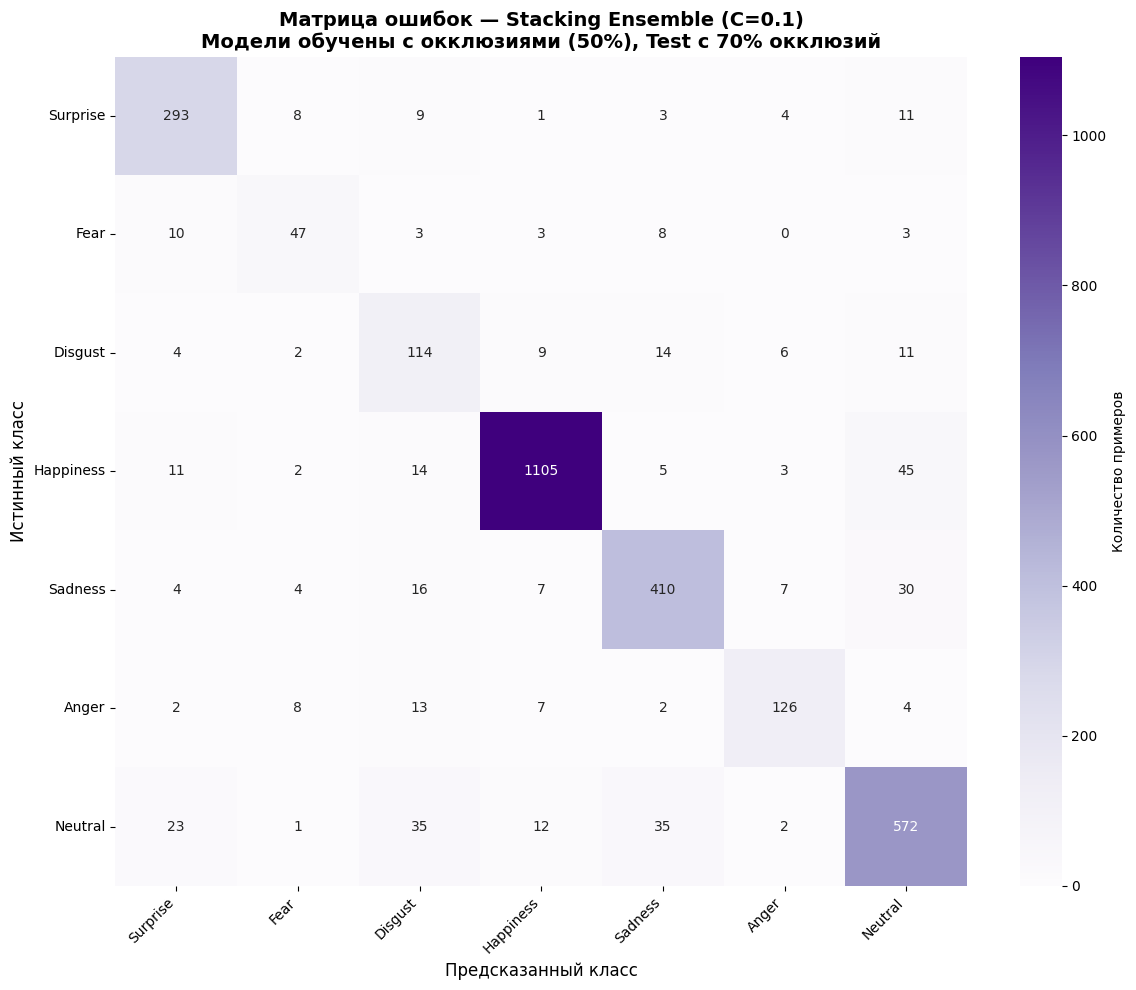

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from tqdm import tqdm
import pickle
from pathlib import Path
from PIL import Image
import timm
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import os

import matplotlib.pyplot as plt
import seaborn as sns


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

PATH_EFF = r"C:\Users\Pulse_GL66\Downloads\best_model (12).pth"
PATH_CONV = r"C:\Users\Pulse_GL66\Downloads\best_model (18).pth"
PATH_VIT = r"C:\Users\Pulse_GL66\Downloads\best_model (14).pth"

TRAIN_DIR = r"D:\Occlusions\train_occluded_50"
VAL_DIR = r"D:\Occlusions\val_original"
TEST_DIR = r"D:\Occlusions\occluded_test_dataset"

RESULTS_DIR = r"D:\НИР\Final models\ensemble_train_with_occlusion"

BATCH_SIZE = 32


class ViTEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            'vit_small_patch16_224',
            pretrained=pretrained,
            num_classes=num_classes,
            drop_path_rate=0.1
        )

    def forward(self, x):
        return self.backbone(x)


class EfficientNetEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()
        
        weights = models.EfficientNet_B2_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.efficientnet_b2(weights=weights)
        in_features = 1408
        
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(in_features, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(p=0.2),
            nn.Linear(256, num_classes)
        )
        
    
    def forward(self, x):
        return self.backbone(x)


class ConvNeXtEmotion(nn.Module):
    def __init__(self, num_classes=7, pretrained=True):
        super().__init__()

        weights = models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1 if pretrained else None
        self.backbone = models.convnext_tiny(weights=weights)

        in_features = 768

        self.backbone.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.LayerNorm(in_features),
            nn.Dropout(p=0.35),
            nn.Linear(in_features, 512),
            nn.GELU(),
            nn.Dropout(p=0.2),
            nn.Linear(512, num_classes)
        )


    def forward(self, x):
        return self.backbone(x)


class SimpleDataset(Dataset):
    def __init__(self, root_dir):
        self.root_dir = Path(root_dir)
        self.images = []
        self.labels = []
        self._load_data()

        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
        ])

    def _load_data(self):
        for class_folder in sorted(self.root_dir.iterdir()):
            if not class_folder.is_dir():
                continue
            try:
                class_idx = int(class_folder.name)
                if class_idx not in range(1, 8):
                    continue
                label = class_idx - 1
                for img_path in class_folder.glob('*.[jp][pn]g'):
                    self.images.append(str(img_path))
                    self.labels.append(label)
            except Exception as e:
                continue

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = self.images[idx]
        label = self.labels[idx]

        image = Image.open(img_path).convert('RGB')
        image = self.transform(image)

        return image, torch.tensor(label, dtype=torch.long)


def create_occluded_dataloaders(batch_size):
    emotion_labels = {
        0: 'Surprise', 1: 'Fear', 2: 'Disgust', 3: 'Happiness',
        4: 'Sadness', 5: 'Anger', 6: 'Neutral'
    }

    train_dataset = SimpleDataset(TRAIN_DIR)
    val_dataset = SimpleDataset(VAL_DIR)
    test_dataset = SimpleDataset(TEST_DIR)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, pin_memory=True)

    return train_loader, val_loader, test_loader, emotion_labels


def load_model(model_class, path, num_classes=7):
    model = model_class(num_classes=num_classes).to(device)
    if os.path.exists(path):
        checkpoint = torch.load(path, map_location=device, weights_only=False)
        if 'model_state_dict' in checkpoint:
            model.load_state_dict(checkpoint['model_state_dict'])
        else:
            model.load_state_dict(checkpoint)
    model.eval()
    return model


def get_model_probs(model, loader):
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Предсказания {model.__class__.__name__}"):
            inputs = inputs.to(device)
            outputs = model(inputs)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
            all_labels.append(labels.numpy())
    
    return np.vstack(all_probs), np.concatenate(all_labels)


model_eff = load_model(EfficientNetEmotion, PATH_EFF)
model_conv = load_model(ConvNeXtEmotion, PATH_CONV)
model_vit = load_model(ViTEmotion, PATH_VIT)

models = [model_eff, model_conv, model_vit]
model_names = ['EfficientNet-B2', 'ConvNeXt-Tiny', 'ViT-Small']

train_loader, val_loader, test_loader, emotion_labels = create_occluded_dataloaders(BATCH_SIZE)

print(f"  Train: {len(train_loader.dataset):6d} изображений")
print(f"  Val:   {len(val_loader.dataset):6d} изображений")
print(f"  Test:  {len(test_loader.dataset):6d} изображений")

print("\nПодготовка данных для Stacking")

val_probs_list = []
test_probs_list = []
val_labels = None
test_labels = None

for model in models:
    val_p, val_l = get_model_probs(model, val_loader)
    test_p, test_l = get_model_probs(model, test_loader)
    
    val_probs_list.append(val_p)
    test_probs_list.append(test_p)
    
    if val_labels is None:
        val_labels = val_l
        test_labels = test_l

X_val = np.hstack(val_probs_list)
X_test = np.hstack(test_probs_list)

print(f"Размер признакового пространства: {X_val.shape[1]}")
print(f"Размер валидационной выборки: {X_val.shape[0]}")


print("\n")
print("ПОДБОР ГИПЕРПАРАМЕТРА C (5-fold стратифицированная кросс-валидация)")
print("\n")


param_grid = {'C': [0.1, 0.3, 0.5, 0.8, 1.0, 2.0, 5.0]}


cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


base_lr = LogisticRegression(
    max_iter=2000,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

# GridSearchCV
grid_search = GridSearchCV(
    base_lr,
    param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("Поиск лучшего C")
grid_search.fit(X_val, val_labels)

best_C = grid_search.best_params_['C']
print(f"\nЛучший C: {best_C}")
print(f"Лучшая accuracy (кросс-валидация): {grid_search.best_score_:.4f} (+- {grid_search.cv_results_['std_test_score'][grid_search.best_index_]:.4f})")

print("\nРезультаты по всем C:")
for i, C in enumerate(param_grid['C']):
    print(f"  C={C}: {grid_search.cv_results_['mean_test_score'][i]:.4f} (+- {grid_search.cv_results_['std_test_score'][i]:.4f})")


print("\n")
print("ОБУЧЕНИЕ ФИНАЛЬНОЙ МЕТА-МОДЕЛИ")
print("\n")

meta_model = LogisticRegression(
    max_iter=2000,
    C=best_C,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

meta_model.fit(X_val, val_labels)
print(f"Мета-модель обучена с C={best_C}")

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Папка создана: {RESULTS_DIR}")

with open(f"{RESULTS_DIR}/meta_model.pkl", "wb") as f:
    pickle.dump(meta_model, f)
print(f"Мета-модель сохранена в {RESULTS_DIR}/meta_model.pkl")



val_pred = meta_model.predict(X_val)
test_pred = meta_model.predict(X_test)

print("\n")
print("РЕЗУЛЬТАТЫ STACKING ENSEMBLE")
print("Модели обучены с окклюзиями 50%, тест с 70% окклюзий")
print("\n")

print(f"\nVal Accuracy:   {accuracy_score(val_labels, val_pred):.4f}")
print(f"Test Accuracy:  {accuracy_score(test_labels, test_pred):.4f}")
print(f"Test Macro F1:  {f1_score(test_labels, test_pred, average='macro'):.4f}")

print("\nPer-class F1-score (Stacking):")
print(classification_report(test_labels, test_pred, 
                          target_names=list(emotion_labels.values()), 
                          digits=3))

print("\nМАТРИЦА ОШИБОК (Test Set с 70% окклюзий)")

cm = confusion_matrix(test_labels, test_pred)

print("    " + " ".join(f"{name:>8}" for name in emotion_labels.values()))
for i, row in enumerate(cm):
    label = list(emotion_labels.values())[i]
    print(f"{label:8} " + " ".join(f"{x:8}" for x in row))

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=list(emotion_labels.values()),
            yticklabels=list(emotion_labels.values()),
            cbar_kws={'label': 'Количество примеров'})

plt.title(f'Матрица ошибок — Stacking Ensemble (C={best_C})\nМодели обучены с окклюзиями (50%), Test с 70% окклюзий', 
          fontsize=14, fontweight='bold')
plt.ylabel('Истинный класс', fontsize=12)
plt.xlabel('Предсказанный класс', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()


print(f"\nИТОГОВАЯ ТОЧНОСТЬ НА ТЕСТЕ (70% ОККЛЮЗИЙ): {accuracy_score(test_labels, test_pred)*100:.2f}%")
print(f"Лучший C (подобран по кросс-валидации): {best_C}")